# Hackaton - Group 4 - Sofia Michael Yash Omar

Time spent: 20 hours

Difficulty: 7/10

## Import Libraries and Download the Data

In [1]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path

import pandas as pd
import numpy as np
from collections import Counter, defaultdict
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import NMF
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
import warnings

from scipy import stats


# DAY 1 : Explore NGO campaigns data

## Preparing Data

In [2]:
files = [
    "sigwatch_data/2010_data_sigwatch.dta",
    "sigwatch_data/2011_data_sigwatch.dta",
    "sigwatch_data/2012_data_sigwatch.dta",
    "sigwatch_data/2013_data_sigwatch.dta",
    "sigwatch_data/2014_data_sigwatch.dta",
    "sigwatch_data/2015_data_sigwatch.dta",
    "sigwatch_data/2016_data_sigwatch.dta",
    "sigwatch_data/2017_data_sigwatch.dta",
    "sigwatch_data/2018_data_sigwatch.dta"
]

In [3]:
# Load and combine all datasets
df_list = [pd.read_stata(file) for file in files]
ngo_data = pd.concat(df_list, ignore_index=True)

In [4]:
print("Combined dataset shape:", ngo_data.shape)
ngo_data.head()

Combined dataset shape: (73094, 94)


,uid_archive,date,company_code,company,company_type,company_parent_code,company_parent,company_parent_country,sentiment,prominence,...,industry_sector_code3,industry_sector3,industry_sector_code4,industry_sector4,report,link1,link2,link3,link4,link5
0,36273,2010-10-01,67,Tesoro,Parent,67,Tesoro,US,-1,2,...,1332.0,Renewable energy,NaN,NaN,"In the U.S., Consumers Union added its influen...",http://www.consumersunion.org/pub/core_other_i...,,,,NaN
1,36273,2010-10-01,103,Valero Energy Corporation,Parent,103,Valero Energy Corporation,US,-1,2,...,1332.0,Renewable energy,NaN,NaN,"In the U.S., Consumers Union added its influen...",http://www.consumersunion.org/pub/core_other_i...,,,,NaN
2,36247,2010-01-06,4,Pfizer,Parent,4,Pfizer,US,-1,2,...,NaN,,NaN,NaN,"<p>In Japan, Medwatcher/Yakugai demanded Pfize...",http://www.yakugai.gr.jp/en/topics/topic.php?i...,,,,NaN
3,35283,2010-12-23,277,C&A,Parent,277,C&A,Germany,0,2,...,NaN,,NaN,NaN,", while Lee, Wrangler and Benetton have agreed...",http://www.evb.ch/p25018978.html,,,,NaN
4,35283,2010-12-23,282,Levi Strauss & Co,Parent,282,Levi Strauss & Co,US,0,2,...,NaN,,NaN,NaN,", while Lee, Wrangler and Benetton have agreed...",http://www.evb.ch/p25018978.html,,,,NaN


In [32]:
ngo_data['ngo_name1']

0                     Consumers Union USA
1                     Consumers Union USA
2                        Medwatcher Japan
3                   Berne Declaration EvB
4                   Berne Declaration EvB
                       ...               
73089    Greenpeace East Asia / Hong Kong
73090    Greenpeace East Asia / Hong Kong
73091    Greenpeace East Asia / Hong Kong
73092    Greenpeace East Asia / Hong Kong
73093    Greenpeace East Asia / Hong Kong
Name: ngo_name1, Length: 73094, dtype: object

### Filter only banks from US, UK, and EU

In [5]:
banks_data = ngo_data[
    (
        ngo_data[['industry_sector1', 'industry_sector2', 'industry_sector3']]
        .isin(['Finance', 'Insurance'])
        .any(axis=1)
    ) &
    (ngo_data['company_parent_country'].isin([
        'US', 'USA', 'UK',
        'Germany', 'France', 'Italy', 'Spain', 'Netherlands', 'Belgium',
        'Ireland', 'Austria', 'Portugal', 'Sweden', 'Finland', 'Denmark',
        'Poland', 'Luxembourg', 'Czech Republic', 'Greece'
    ]))
].reset_index(drop=True)

In [6]:
print("Filtered dataset shape:", banks_data.shape)
banks_data.head()

Filtered dataset shape: (8484, 94)


,uid_archive,date,company_code,company,company_type,company_parent_code,company_parent,company_parent_country,sentiment,prominence,...,industry_sector_code3,industry_sector3,industry_sector_code4,industry_sector4,report,link1,link2,link3,link4,link5
0,35274,2010-12-23,18,AREVA,Parent,18,AREVA,France,-1,2,...,1336.0,Finance,NaN,NaN,"In Germany, Urgewald published a report critic...",http://www.urgewald.de/index.php?page=3-64-156...,,,,NaN
1,35274,2010-12-23,65,Vattenfall,Parent,65,Vattenfall,Sweden,-1,2,...,1336.0,Finance,NaN,NaN,"In Germany, Urgewald published a report critic...",http://www.urgewald.de/index.php?page=3-64-156...,,,,NaN
2,35274,2010-12-23,171,Deutsche Bank,Parent,171,Deutsche Bank,Germany,-2,4,...,1336.0,Finance,NaN,NaN,"In Germany, Urgewald published a report critic...",http://www.urgewald.de/index.php?page=3-64-156...,,,,NaN
3,35274,2010-12-23,174,RWE,Parent,174,RWE,Germany,-1,2,...,1336.0,Finance,NaN,NaN,"In Germany, Urgewald published a report critic...",http://www.urgewald.de/index.php?page=3-64-156...,,,,NaN
4,35274,2010-12-23,240,E.ON AG,Parent,240,E.ON AG,Germany,-1,2,...,1336.0,Finance,NaN,NaN,"In Germany, Urgewald published a report critic...",http://www.urgewald.de/index.php?page=3-64-156...,,,,NaN


In [7]:
banks_data["company_parent_country"] = banks_data["company_parent_country"].replace("USA", "US")

### Descriptive Analyses

In [8]:
# Count positive/negative campaigns
print(banks_data['sentiment'].value_counts())

sentiment
-2    3780
-1    2990
 1     745
 2     510
 0     459
Name: count, dtype: int64


In [9]:
# Share of each sentiment class
sentiment_counts = banks_data['sentiment'].value_counts().sort_index()
sentiment_share = (sentiment_counts / sentiment_counts.sum() * 100).round(2)

In [10]:
print("Sentiment share (%):")
print(sentiment_share)

Sentiment share (%):
sentiment
-2    44.55
-1    35.24
 0     5.41
 1     8.78
 2     6.01
Name: count, dtype: float64


More than 80% of NGO campaigns directed at banks are negative or very negative.
This reflects strong and persistent NGO pressure on the financial sector, often linked to issues such as fossil-fuel financing, ethical lending, and transparency.

In [11]:
#Sentiment by country
sentiment_country = banks_data.groupby('company_parent_country')['sentiment'].mean().sort_values()

print("Average sentiment by country (lower = more negative):")
print(sentiment_country)


Average sentiment by country (lower = more negative):
company_parent_country
Czech Republic   -1.750000
Spain            -1.514223
Greece           -1.500000
Poland           -1.453333
US               -1.187351
Luxembourg       -1.169811
Italy            -1.122581
Germany          -1.065079
Ireland          -1.052632
UK               -1.044153
Austria          -1.033333
France           -1.030831
Denmark          -0.865116
Finland          -0.800000
Portugal         -0.758065
Sweden           -0.619217
Netherlands      -0.492662
Belgium          -0.413462
Name: sentiment, dtype: float64


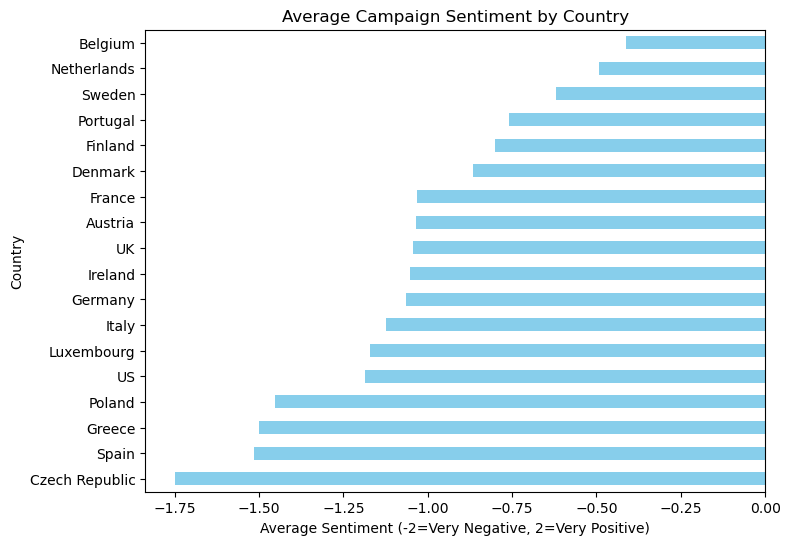

In [12]:
# bar plot
sentiment_country.plot(kind='barh', figsize=(8,6), color='skyblue')
plt.title("Average Campaign Sentiment by Country")
plt.xlabel("Average Sentiment (-2=Very Negative, 2=Very Positive)")
plt.ylabel("Country")
plt.show()

Czech Republic is by the country with the highest average negative sentiment at -1.75. Spain, Greece, and Poland all have average sentiment in similar range of -1.5 to -1.6. 
The US comes next with an average sentiment of -1.20, while the UK appears around the -1.00 mark.

Belgium and the Netheralands have the least negative average sentiment at around -0.40 and -0.50 respectively.

It is important to note that we have varying different sizes of economies and banking sectors in these countries, which could influence the number and nature of NGO campaigns.

In [13]:
#Sentiment by country
number_of_campaigns = banks_data.groupby('company_parent_country')['sentiment'].count().sort_values()

print("Number of campaign by country:")
print(number_of_campaigns)


Number of campaign by country:
company_parent_country
Greece               4
Czech Republic       4
Ireland             19
Finland             25
Austria             30
Portugal            62
Poland              75
Belgium            104
Luxembourg         106
Italy              155
Denmark            215
Sweden             281
Spain              457
Germany            630
France             746
Netherlands        954
UK                1676
US                2941
Name: sentiment, dtype: int64


As already theorised we can see that the sentiment of countries like USA, UK has a much higher sample size compared to smaller Economies.

In [43]:
Eu = ['Germany', 'France', 'Italy', 'Spain', 'Netherlands', 'Belgium',
        'Ireland', 'Austria', 'Portugal', 'Sweden', 'Finland', 'Denmark',
        'Poland', 'Luxembourg', 'Czech Republic', 'Greece']

mask = ngo_data['company_parent_country'].isin(Eu)

sentiment_EU = banks_data.loc[mask, 'sentiment'].mean()
sentiment_US = sentiment_country['US']
sentiment_UK = sentiment_country['UK']

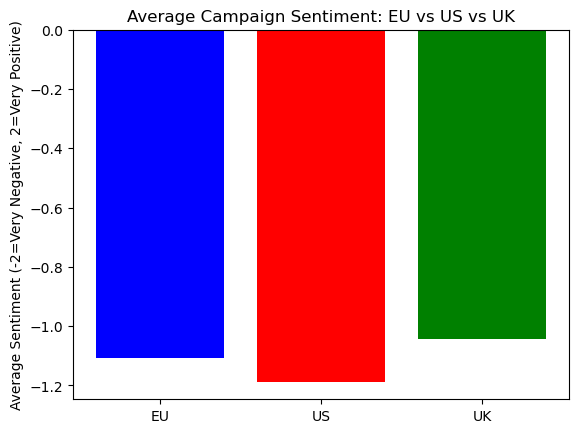

In [44]:
labels = ['EU', 'US', 'UK']
values = [sentiment_EU, sentiment_US, sentiment_UK]

plt.bar(labels, values, color=['blue', 'red', 'green'])
plt.title("Average Campaign Sentiment: EU vs US vs UK")
plt.ylabel("Average Sentiment (-2=Very Negative, 2=Very Positive)")
plt.show()

Grouping the EU countries together, we see that as a whole, the sentiments are quite similar to those in the US and UK, with an average sentiment of around -1.00 to -1.20, with the UK being the least negative and the US being the most negative.

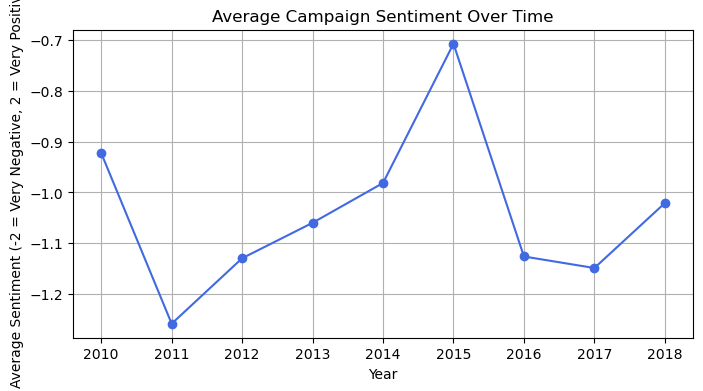

In [14]:
banks_data['year'] = pd.to_datetime(banks_data['date'], errors='coerce').dt.year
sentiment_trend = banks_data.groupby('year')['sentiment'].mean()

plt.figure(figsize=(8,4))
plt.plot(sentiment_trend.index, sentiment_trend.values, marker='o', linestyle='-', color='royalblue')
plt.title("Average Campaign Sentiment Over Time")
plt.xlabel("Year")
plt.ylabel("Average Sentiment (-2 = Very Negative, 2 = Very Positive)")
plt.grid(True)
plt.show()

2011 is by far the year with the average lowest sentiment, while 2015 is the year with the highest average sentiment, however still negative. The former could be linked to the aftermath of the 2008 financial crisis, with NGOs ramping up pressure on banks in the following years. The latter could be linked to increased regulations and reforms in the banking sector, leading to slightly more positive NGO campaigns.

In [15]:
# Combine all 5 possible NGO name columns into one long list
ngo_cols = ['ngo_name1', 'ngo_name2', 'ngo_name3', 'ngo_name4', 'ngo_name5']

# Flatten the columns into one Series, remove missing values, and get unique names
ngo_names = pd.Series(banks_data[ngo_cols].values.ravel()).dropna().unique()

# Count unique NGOs and unique firms
num_ngos = len(ngo_names)
num_firms = banks_data['company_parent'].nunique()

In [16]:
# Print the results
print(f"Unique NGOs involved: {num_ngos}")
print(f"Unique firms targeted: {num_firms}")

Unique NGOs involved: 883
Unique firms targeted: 1485


- That’s a large and diverse set of NGOs, meaning many different organizations have been active in campaigning against or engaging with financial institutions.
→ This suggests wide public and NGO attention to the banking sector’s sustainability practices.
- Over 500 distinct banks or financial institutions were targeted across the US, UK, and EU.
→ The campaigns are spread across many actors, showing systemic scrutiny rather than isolated events.

In [17]:
ngo_power_cols = ['ngo_power1', 'ngo_power2', 'ngo_power3', 'ngo_power4', 'ngo_power5']

In [18]:
ngo_powers = pd.to_numeric(pd.Series(banks_data[ngo_power_cols].values.ravel()), errors='coerce')

print("NGO Power summary (all NGOs combined):")
print(ngo_powers.describe())

NGO Power summary (all NGOs combined):
count    12739.000000
mean         1.558914
std          0.628094
min          0.500000
25%          1.000000
50%          1.500000
75%          2.500000
max          2.750000
dtype: float64


- The average NGO power value (~1.5) suggests that **moderately influential NGOs** are most active in campaigns against banks.  
- The presence of higher values (above 2.0) indicates that **a subset of well-known, high-impact NGOs** (e.g., Greenpeace, Oxfam) occasionally lead campaigns.  
- Overall, the distribution is **skewed toward mid-level influence**, implying that both global and local NGOs contribute to financial-sector activism.


In [19]:
# Stack all NGO columns together
ngo_list = []
for i in range(5):
    temp = banks_data[[ngo_cols[i], ngo_power_cols[i]]].dropna()
    temp.columns = ['ngo_name', 'ngo_power']
    ngo_list.append(temp)

ngo_long = pd.concat(ngo_list, ignore_index=True)

# Clean up whitespace or duplicates
ngo_long['ngo_name'] = ngo_long['ngo_name'].str.strip()
ngo_long = ngo_long[ngo_long['ngo_name'] != '']

In [20]:
#summarize by ngo
ngo_summary = ngo_long.groupby('ngo_name').agg(
    avg_power=('ngo_power', 'mean'),
    campaign_count=('ngo_power', 'count')
).reset_index()

# Sort by most active or most powerful NGOs
ngo_summary = ngo_summary.sort_values(by='avg_power', ascending=False)

ngo_summary.head(10)

,ngo_name,avg_power,campaign_count
707,ResponsiBank Indonesia,2.75,2
860,Western Sahara Resource Watch WSRW,2.75,13
445,Health Care Without Harm (HCWH) Europe,2.75,2
804,Unfriend Coal,2.75,24
269,ECA Watch,2.75,2
783,Transnational Institute,2.75,2
772,Tax Justice Network TJN,2.75,18
771,Tax Justice Network - Norway,2.75,1
770,Tax Justice Network - Africa / TJNA,2.75,2
195,Cluster Munition Coalition (CMC),2.75,9


/var/folders/x4/7vf731f159n349vn3wlmypn00000gn/T/ipykernel_56691/2940855150.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_ngos, y='ngo_name', x='avg_power', palette='crest')


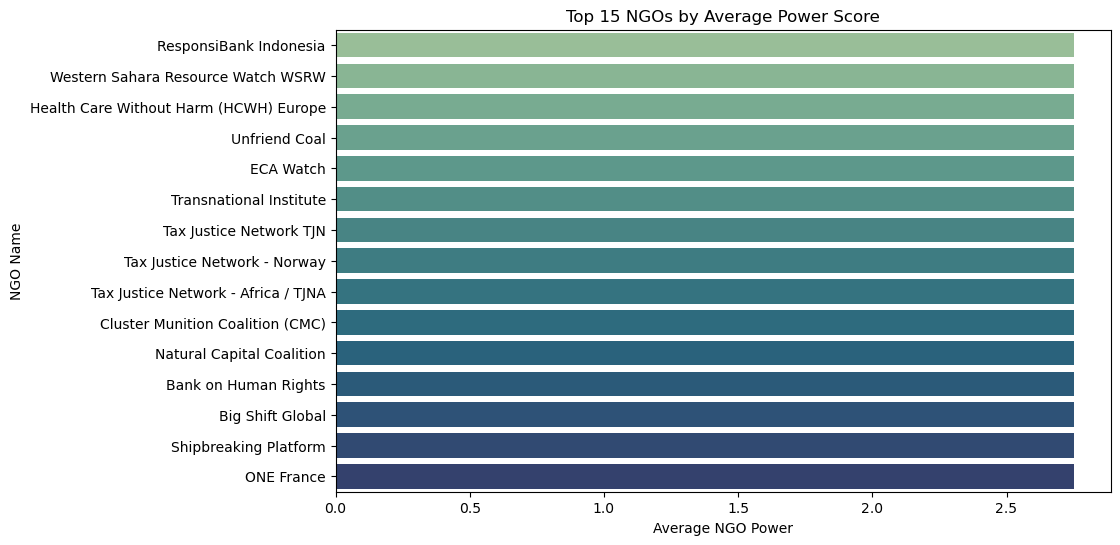

In [21]:
#top 15 ngo by power

plt.figure(figsize=(10,6))
top_ngos = ngo_summary.nlargest(15, 'avg_power')
sns.barplot(data=top_ngos, y='ngo_name', x='avg_power', palette='crest')
plt.title("Top 15 NGOs by Average Power Score")
plt.xlabel("Average NGO Power")
plt.ylabel("NGO Name")
plt.show()

- The most influential NGOs include **Big Shift Global, Tax Justice Network, Norway, Shipbreaking Platform, and Transnational Institute (TNI)**, each with an average power score of around **2.75**, the upper end of the scale.  
- Organizations such as **Facing Finance, BankTrack, Stand.earth, and Survival International** appear frequently across campaigns, suggesting they are both **active and reputable voices** in financial-sector accountability.  
- The majority of high-power NGOs operate in the **finance, environmental, and human rights advocacy spaces**, indicating that NGO activism around banks is led by groups with **strong international credibility**.  
- The narrow range of power values (2.5–2.75) implies that **a relatively small group of well-recognized NGOs dominates the discourse**, while smaller NGOs play a more limited role.


> High-profile NGOs, particularly those focused on financial transparency, fossil-fuel divestment, and ethical investment, are driving the majority of influential campaigns against banks.  
> Their consistent presence reinforces the **concentrated nature of NGO pressure**, where a few key players shape the overall ESG narrative in the financial sector.


In [22]:
# Summary statistics for prominence
banks_data['prominence'].describe()

count    8484.000000
mean        2.409712
std         0.959380
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000
max         4.000000
Name: prominence, dtype: float64

<Axes: title={'center': 'Distribution of Campaign Prominence'}, ylabel='Frequency'>

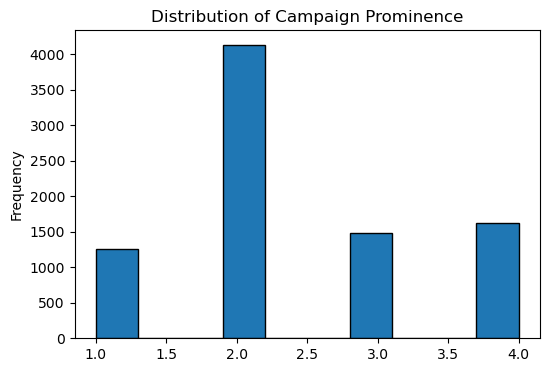

In [23]:
# plot distribution
banks_data['prominence'].plot(kind='hist', bins=10, edgecolor='black', figsize=(6,4), title='Distribution of Campaign Prominence')

The distribution of the prominence variable shows that most NGO campaigns against banks have **moderate visibility**:

- The majority of cases cluster around **level 2**, indicating **regional or sector-level coverage** rather than global attention.  
- Fewer campaigns reach **high prominence (levels 3–4)**, suggesting that only a limited number of issues become widely publicized or mobilize large NGO coalitions.  
- A smaller share of campaigns remain at **low visibility (level 1)**, typically local or single-organization actions.  


In [24]:
# Calculate the average NGO power across the five columns
banks_data['avg_ngo_power'] = banks_data[ngo_power_cols].mean(axis=1)

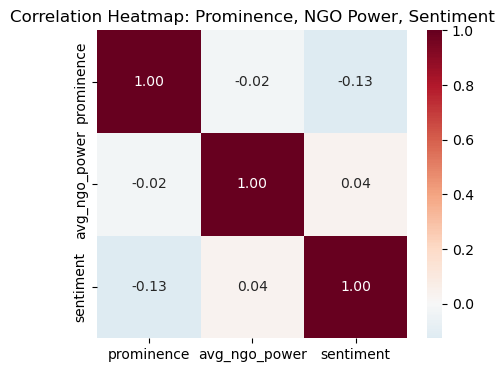

In [25]:
# Correlation matrics
corr_vars = banks_data[['prominence', 'avg_ngo_power', 'sentiment']]
corr = corr_vars.corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title("Correlation Heatmap: Prominence, NGO Power, Sentiment")
plt.show()

- Campaigns remain **predominantly negative** (≈80%), yet the correlation between **prominence and sentiment (–0.13)** suggests that **high-visibility campaigns tend to be slightly more critical**.  
  → Major controversies (e.g., fossil-fuel financing, unethical lending) are the ones that attract the most public attention.
- The near-zero correlation between **NGO power and prominence (–0.01)** indicates that **NGO influence does not automatically translate into wider media visibility**, smaller or mid-level NGOs can still drive attention if the issue resonates publicly.  
- The weak positive link between **NGO power and sentiment (+0.11)** shows that **more influential NGOs may adopt a somewhat more balanced tone**, possibly due to their reputational stakes or preference for strategic engagement over confrontation.  
- With **average NGO power around 1.5** and **moderate prominence levels**, most campaigns appear **localized or sector-specific**, not global-scale movements.


## TASK 1 - Media Coverage

In [28]:
# sample up to 100 random rows per year from ngo_data
banks_data = banks_data.copy()
banks_data['year'] = pd.to_datetime(banks_data['date'], errors='coerce').dt.year

banks_sample_100 = (
    banks_data.dropna(subset=['year'])
            .groupby('year', group_keys=False)
            .apply(lambda g: g.sample(n=100, random_state=42) if len(g) >= 100 else g.sample(n=len(g), random_state=42))
            .reset_index(drop=True)
)

# quick check
print("Total sampled rows:", banks_sample_100.shape[0])
print(banks_sample_100['year'].value_counts().sort_index())

Total sampled rows: 900
year
2010    100
2011    100
2012    100
2013    100
2014    100
2015    100
2016    100
2017    100
2018    100
Name: count, dtype: int64


/var/folders/x4/7vf731f159n349vn3wlmypn00000gn/T/ipykernel_56691/3165797531.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=100, random_state=42) if len(g) >= 100 else g.sample(n=len(g), random_state=42))


### Web Scraping Internet Archive

In [45]:
import pandas as pd
import internetarchive
from datetime import datetime, timedelta
import time

# Ensure date column is in datetime format
banks_sample_100['date'] = pd.to_datetime(banks_sample_100['date'])

# Function to query Internet Archive for each row
def count_archive_hits(company, ngo, date):
    """
    Search the Internet Archive for the company name within a small date window.
    Returns the number of matching items.
    """
    if pd.isna(company) or pd.isna(date):
        return 0

    company_str = str(company).strip()
    ngo_str = str(ngo).strip() if pd.notna(ngo) else ""
    start_date = (date - timedelta(days=2)).strftime('%Y-%m-%d')
    end_date = (date + timedelta(days=10)).strftime('%Y-%m-%d')

    if company_str == "":
        return 0
    
    query = f'"{company_str}" AND "{ngo_str}" AND date:[{start_date} TO {end_date}]'

    try:
        search = internetarchive.search_items(query, max_retries = 2)
        # Count hits efficiently
        num_hits = sum(1 for _ in search.iter_as_items())  # count total
        return num_hits

    except Exception as e:
        print(f"Error for {company} on {date}: {e}")
        return 0


# Apply the search (⚠️ slow if dataset is large)
results = []
for idx, row in banks_sample_100.iterrows():
    print(f'{idx}/{banks_sample_100.shape[0]}')
    hits = count_archive_hits(row['company'], row['ngo_name1'], row['date'])
    results.append(hits)
    # Small delay to be kind to the API
    time.sleep(1)

# Add to dataframe
banks_sample_100['archive_hits'] = results

# Save results
banks_sample_100.to_csv("banks_sample_with_archive_hits.csv", index=False)
print("✅ Done! Added 'archive_hits' column.")

0/900
1/900
2/900
3/900
4/900
5/900
6/900
7/900
8/900
9/900
10/900
11/900
12/900
13/900
14/900
15/900
16/900
17/900
18/900
19/900
20/900
21/900
22/900
23/900
24/900
25/900
26/900
27/900
28/900
29/900
30/900
31/900
32/900
33/900
34/900
35/900
36/900
37/900
38/900
39/900
40/900
41/900
42/900
43/900
44/900
45/900
46/900
47/900
48/900
49/900
50/900
51/900
52/900
53/900
54/900
55/900
56/900
57/900
58/900
59/900
60/900
61/900
62/900
63/900
64/900
65/900
66/900
67/900
68/900
69/900
70/900
71/900
72/900
73/900
74/900
75/900
76/900
77/900
78/900
79/900
80/900
81/900
82/900
83/900
84/900
85/900
86/900
87/900
88/900
89/900
90/900
91/900
92/900
93/900
94/900
95/900
96/900
97/900
98/900
99/900
100/900
101/900
102/900
103/900
104/900
105/900
106/900
107/900
108/900
109/900
110/900
111/900
112/900
113/900
114/900
115/900
116/900
117/900
118/900
119/900
120/900
121/900
122/900
123/900
124/900
125/900
126/900
127/900
128/900
129/900
130/900
131/900
132/900
133/900
134/900
135/900
136/900
137/900
138/90

In [46]:
banks_sample_100['archive_hits'].value_counts()

archive_hits
0    899
1      1
Name: count, dtype: int64

Surprisingly, our scraping of the Internet Archive yielded almost no results. This could be due to these campaigns not being widely covered in archived web content, or limitations in the search capabilities of the Internet Archive API.

They could also be due to a lack of media coverage for many NGO campaigns, especially those led by smaller organizations or focused on niche issues. To further improve our results, we will use a dataset that contains CNN articles to check for media coverage of the NGO campaigns against banks.


In [53]:
news = pd.read_csv("CNN_Articels_clean.csv")
news = news.drop(columns={"Description", "Keywords", "Second headline", "Article text", "Author", "Category", "Section", "Index"})

In [54]:
# Convert 'date_published' to date only (drop time component)
news['Date published'] = pd.to_datetime(news['Date published'], errors='coerce').dt.date

# Quick check
news[['Date published']].head()

,Date published
0,2021-07-15
1,2021-05-12
2,2021-06-16
3,2022-03-15
4,2022-03-15


In [55]:
news = news.sort_values(by=["Date published"], ascending=True)

In [56]:
news.head(4)

,Date published,Url,Headline
2076,2012-12-06,https://www.cnn.com/2012/12/06/world/europe/du...,Duchess Catherine Fast Facts - CNN
3391,2012-12-13,https://www.cnn.com/2012/12/13/world/europe/da...,David Cameron Fast Facts - CNN
3850,2012-12-14,https://www.cnn.com/2012/12/14/world/europe/ki...,King Juan Carlos I Fast Facts - CNN
2355,2012-12-21,https://www.cnn.com/2012/12/21/world/europe/fr...,Francois Hollande Fast Facts - CNN


In [59]:
# create subset of ngo_data that matches the timeline of utterances_df
start = news['Date published'].min()
end = news['Date published'].max()

if pd.isna(start) or pd.isna(end):
    raise ValueError("utterances_df has NaT for min/max timestamp")

# ensure dates are normalized datetimes for fair comparison
banks_sample_100['date'] = pd.to_datetime(banks_sample_100['date'], errors='coerce').dt.normalize()
start = pd.to_datetime(start).normalize()
end = pd.to_datetime(end).normalize()

banks_sample_100 = banks_sample_100[(banks_sample_100['date'] >= start) & (banks_sample_100['date'] <= end)].reset_index(drop=True)

print(f"utterances timeline: {start.date()} -> {end.date()}")
print("Original ngo_data rows:", len(ngo_data))
print("Subset rows (ngo_data_timeline):", len(banks_sample_100))

utterances timeline: 2012-12-06 -> 2022-03-15
Original ngo_data rows: 73094
Subset rows (ngo_data_timeline): 605


In [ ]:
import pandas as pd
from datetime import timedelta
from tqdm import tqdm

news['Date published'] = pd.to_datetime(news['Date published'], errors='coerce')
banks_sample_100['date'] = pd.to_datetime(banks_sample_100['date'], errors='coerce')

news['Headline_lower'] = news['Headline'].str.lower()

def count_company_mentions(company, ref_date, window=7):
    if pd.isna(company) or pd.isna(ref_date):
        return 0

    company_str = str(company).strip()
    if company_str == "":
        return 0

    start_date = ref_date
    end_date = ref_date + timedelta(days=window)
    company_lower = company_str.lower()

    mask = (news['Date published'] >= start_date) & (news['Date published'] <= end_date)
    subset = news.loc[mask, 'Headline_lower']


    return subset.str.contains(company_lower, na=False, regex=False).sum()

tqdm.pandas(desc="Checking company mentions")
banks_sample_100['mentions_next_7d'] = banks_sample_100.progress_apply(
    lambda row: count_company_mentions(row['company_parent'], row['date']), axis=1
)

Checking company mentions: 100%|██████████| 605/605 [00:00<00:00, 2618.87it/s]


In [61]:
banks_sample_100['mentions_next_7d'].value_counts()

mentions_next_7d
0    602
1      3
Name: count, dtype: int64

Once again we see that there is minimal media coverage of NGO campaigns against banks. This could be due to a lack of media interest in these campaigns, or it could be that the campaigns are not widely publicized, potentially indicating a gap between NGO activities and mainstream media attention or influence of banks in shaping media narratives.

We conduct a similar analysis using the entire NGO dataset on the CNN articles dataset. 

### CNN Articles Analysis

In [62]:
# create subset of ngo_data that matches the timeline of utterances_df
start = news['Date published'].min()
end = news['Date published'].max()

if pd.isna(start) or pd.isna(end):
    raise ValueError("utterances_df has NaT for min/max timestamp")

# ensure dates are normalized datetimes for fair comparison
ngo_data['date'] = pd.to_datetime(ngo_data['date'], errors='coerce').dt.normalize()
start = pd.to_datetime(start).normalize()
end = pd.to_datetime(end).normalize()

ngo_data = ngo_data[(ngo_data['date'] >= start) & (ngo_data['date'] <= end)].reset_index(drop=True)

print(f"utterances timeline: {start.date()} -> {end.date()}")
print("Original ngo_data rows:", len(ngo_data))
print("Subset rows (ngo_data_timeline):", len(ngo_data))

utterances timeline: 2012-12-06 -> 2022-03-15
Original ngo_data rows: 56614
Subset rows (ngo_data_timeline): 56614


In [98]:
import pandas as pd
from datetime import timedelta
from tqdm import tqdm

news['Date published'] = pd.to_datetime(news['Date published'], errors='coerce')
ngo_data['date'] = pd.to_datetime(ngo_data['date'], errors='coerce')

news['Headline_lower'] = news['Headline'].str.lower()

def count_company_mentions(company, ref_date, window=7):
    if pd.isna(company) or pd.isna(ref_date):
        return 0

    company_str = str(company).strip()
    if company_str == "":
        return 0

    start_date = ref_date
    end_date = ref_date + timedelta(days=window)
    company_lower = company_str.lower()

    mask = (news['Date published'] >= start_date) & (news['Date published'] <= end_date)
    subset = news.loc[mask, 'Headline_lower']


    return subset.str.contains(company_lower, na=False, regex=False).sum()

tqdm.pandas(desc="Checking company mentions")
ngo_data['mentions_next_7d'] = ngo_data.progress_apply(
    lambda row: count_company_mentions(row['company_parent'], row['date']), axis=1
)

Checking company mentions: 100%|██████████| 56614/56614 [00:08<00:00, 6699.79it/s]


In [99]:
ngo_data['mentions_next_7d'].value_counts()

mentions_next_7d
0    56573
1       35
2        4
4        2
Name: count, dtype: int64

Once again, the data is heavily skewed towards zero mentions, indicating that most NGO campaigns do not receive media coverage in CNN articles. However, there are a few campaigns that do receive some attention, with a small number of campaigns being mentioned multiple times within the 7-day window.

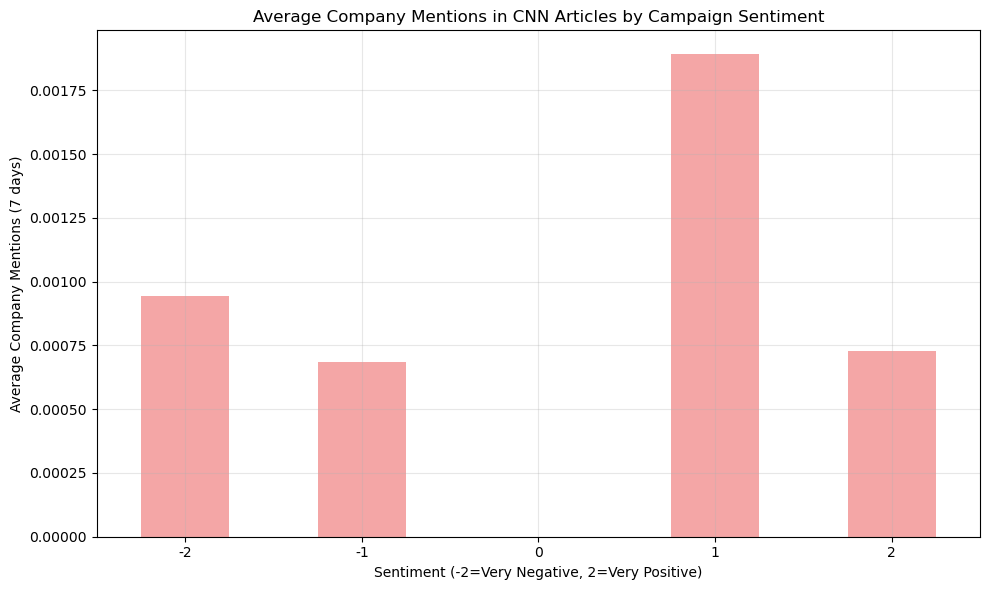

In [105]:
plt.figure(figsize=(10, 6))

# Group by sentiment and calculate mean company mentions
sentiment_company_stats = ngo_data.groupby('sentiment')['mentions_next_7d'].mean()

# Create bar plot
sentiment_company_stats.plot(kind='bar', color='lightcoral', alpha=0.7)
plt.title('Average Company Mentions in CNN Articles by Campaign Sentiment')
plt.xlabel('Sentiment (-2=Very Negative, 2=Very Positive)')
plt.ylabel('Average Company Mentions (7 days)')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


We can discern no real difference between  positive sentiment and negative sentiment campaigns in terms of media coverage, as they both see coverage. However, we have a slight preference to posiitve campaigns indicating that media may be more likely to cover campaigns that present banks in a more favorable light.

Interestingly, campaigns with neutral sentiment appear to receive the least media coverage, suggesting that media outlets may be less interested in covering campaigns that do not take a clear stance on the issues at hand.

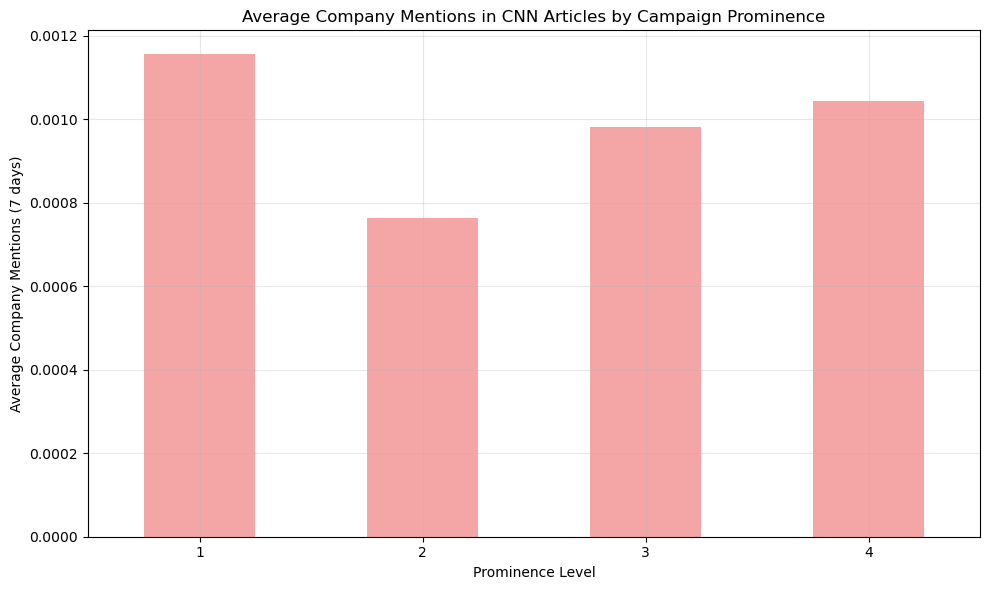

In [109]:
plt.figure(figsize=(10, 6))

# Group by sentiment and calculate mean company mentions
sentiment_company_stats = ngo_data.groupby('prominence')['mentions_next_7d'].mean()

# Filter out prominence level 0
filtered_data = ngo_data[ngo_data['prominence'] != 0]
sentiment_company_stats = filtered_data.groupby('prominence')['mentions_next_7d'].mean()

# Create bar plot
sentiment_company_stats.plot(kind='bar', color='lightcoral', alpha=0.7)
plt.title('Average Company Mentions in CNN Articles by Campaign Prominence')
plt.xlabel('Prominence Level')
plt.ylabel('Average Company Mentions (7 days)')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Here we see that prominence does not have an impact on media coverage, with all levels of prominence seeing minimal mentions in CNN articles. This suggests that even campaigns that are more prominent do not necessarily receive more media attention, indicating a potential disconnect between NGO campaign prominence and media coverage.

### Conclusions

From this task, we can conclude that NGO Campaigns receive minimal media attention, with the majority of campaigns receiving no mentions at all. This suggests a potential disconnect between NGO activities and mainstream media coverage, which could limit the impact and reach of these campaigns.

## TASK 2 - Social Media Coverage

In [65]:
import json
import pandas as pd

with open("AutoNewspaper/conversations.json", "r", encoding="utf-8") as f:
    conversations = json.load(f)

with open("AutoNewspaper/corpus.json", "r", encoding="utf-8") as f:
    corpus = json.load(f)

with open("AutoNewspaper/index.json", "r", encoding="utf-8") as f:
    index = json.load(f)

with open("AutoNewspaper/users.json", "r", encoding="utf-8") as f:
    users = json.load(f)

utterances = []
with open("AutoNewspaper/utterances.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        utterances.append(json.loads(line))

utterances_df = pd.DataFrame(utterances)
users_df = pd.DataFrame(users)
index_df = pd.DataFrame(index)

print("Utterances shape:", utterances_df.shape)
print("Users shape:", users_df.shape)


Utterances shape: (4662066, 7)
Users shape: (0, 5130)


In [66]:
# convert epoch seconds to datetime
utterances_df['timestamp'] = pd.to_datetime(utterances_df['timestamp'], unit='s')

# quick check
utterances_df[['id', 'timestamp']].head()

,id,timestamp
0,5wrk8s,2017-03-01 00:00:20
1,5wrk8v,2017-03-01 00:00:21
2,5wrk91,2017-03-01 00:00:21
3,5wrk95,2017-03-01 00:00:21
4,5wrk99,2017-03-01 00:00:22


In [67]:
# keep only the date (time set to 00:00:00) while preserving datetime dtype
utterances_df['timestamp'] = pd.to_datetime(utterances_df['timestamp'], unit='s').dt.normalize()

In [68]:
utterances_df

,id,user,root,reply_to,timestamp,text,meta
0,5wrk8s,AutoNewspaperAdmin,5wrk8s,None,2017-03-01,,"{'score': 1, 'top_level_comment': None, 'retri..."
1,5wrk8v,AutoNewspaperAdmin,5wrk8v,None,2017-03-01,,"{'score': 1, 'top_level_comment': None, 'retri..."
2,5wrk91,AutoNewspaperAdmin,5wrk91,None,2017-03-01,,"{'score': 1, 'top_level_comment': None, 'retri..."
3,5wrk95,AutoNewspaperAdmin,5wrk95,None,2017-03-01,,"{'score': 1, 'top_level_comment': None, 'retri..."
4,5wrk99,AutoNewspaperAdmin,5wrk99,None,2017-03-01,,"{'score': 1, 'top_level_comment': None, 'retri..."
...,...,...,...,...,...,...,...
4662061,e8tc5mf,PointlessCarnal2018,9t39qb,9t39qb,2018-10-31,Knock it off hermes,"{'score': 1, 'top_level_comment': 'e8tc5mf', '..."
4662062,e8tcoka,KnoWhatImSang,9t3cdn,9t3cdn,2018-10-31,"Well, isn't that nice!","{'score': 1, 'top_level_comment': 'e8tcoka', '..."
4662063,e8tctwa,WinterizedBacon,9t3byl,9t3byl,2018-10-31,As an FYI from a North Dakotan. This law was c...,"{'score': 1, 'top_level_comment': 'e8tctwa', '..."
4662064,e8th0y0,autotldr,9sj3dd,9sj3dd,2018-10-31,"This is the best tl;dr I could make, [original...","{'score': 1, 'top_level_comment': 'e8th0y0', '..."


### Banks Sample

In [80]:
# create subset of ngo_data that matches the timeline of utterances_df
start = utterances_df['timestamp'].min()
end = utterances_df['timestamp'].max()

if pd.isna(start) or pd.isna(end):
    raise ValueError("utterances_df has NaT for min/max timestamp")

# ensure dates are normalized datetimes for fair comparison
banks_sample_100['date'] = pd.to_datetime(banks_sample_100['date'], errors='coerce').dt.normalize()
start = pd.to_datetime(start).normalize()
end = pd.to_datetime(end).normalize()

banks_sample_100 = banks_sample_100[(banks_sample_100['date'] >= start) & (banks_sample_100['date'] <= end)].reset_index(drop=True)

print(f"utterances timeline: {start.date()} -> {end.date()}")
print("Subset rows (banks_sample_100):", len(banks_sample_100))

utterances timeline: 2016-10-29 -> 2018-10-31
Subset rows (banks_sample_100): 210


In [82]:
import pandas as pd
from datetime import timedelta
from tqdm import tqdm

utterances_df['timestamp'] = pd.to_datetime(utterances_df['timestamp'], errors='coerce')
banks_sample_100['date'] = pd.to_datetime(banks_sample_100['date'], errors='coerce')

utterances_df['text'] = utterances_df['text'].str.lower()

def count_campaign_mentions(company, ngo, ref_date, window=7):
    if pd.isna(company) or pd.isna(ngo) or pd.isna(ref_date):
        return 0

    company_str = str(company).strip().lower()
    ngo_str = str(ngo).strip().lower()
    if company_str == "" or ngo_str == "":
        return 0

    start_date = pd.to_datetime(ref_date)
    end_date = start_date + timedelta(days=window)

    mask = (utterances_df['timestamp'] >= start_date) & (utterances_df['timestamp'] <= end_date)
    subset = utterances_df.loc[mask, 'text']
    if subset.empty:
        return 0

    # simple substring search (regex=False). counts posts where BOTH appear
    mentions_company = subset.str.contains(company_str, na=False, regex=False)
    mentions_ngo = subset.str.contains(ngo_str, na=False, regex=False)

    return int((mentions_company & mentions_ngo).sum())

tqdm.pandas(desc="Checking company+NGO mentions")
banks_sample_100['mentions_next_7d_social'] = banks_sample_100.progress_apply(
    lambda row: count_campaign_mentions(row['company_parent'], row.get('ngo_name1', None), row['date']),
    axis=1
)

Checking company+NGO mentions: 100%|██████████| 210/210 [00:03<00:00, 53.83it/s]


In [83]:
banks_sample_100["mentions_next_7d_social"].value_counts()

mentions_next_7d_social
0    210
Name: count, dtype: int64

No mentions for the banks once again. 

### Whole Dataset

In [86]:
# create subset of ngo_data that matches the timeline of utterances_df
start = utterances_df['timestamp'].min()
end = utterances_df['timestamp'].max()

if pd.isna(start) or pd.isna(end):
    raise ValueError("utterances_df has NaT for min/max timestamp")

# ensure dates are normalized datetimes for fair comparison
ngo_data['date'] = pd.to_datetime(ngo_data['date'], errors='coerce').dt.normalize()
start = pd.to_datetime(start).normalize()
end = pd.to_datetime(end).normalize()

ngo_data_social = ngo_data[(ngo_data['date'] >= start) & (ngo_data['date'] <= end)].reset_index(drop=True)

print(f"utterances timeline: {start.date()} -> {end.date()}")
print("Original ngo_data rows:", len(ngo_data))
print("Subset rows (ngo_data_timeline):", len(ngo_data_social))

utterances timeline: 2016-10-29 -> 2018-10-31
Original ngo_data rows: 56614
Subset rows (ngo_data_timeline): 21266


In [87]:
import pandas as pd
from datetime import timedelta
from tqdm import tqdm

utterances_df['timestamp'] = pd.to_datetime(utterances_df['timestamp'], errors='coerce')
ngo_data_social['date'] = pd.to_datetime(ngo_data_social['date'], errors='coerce')

utterances_df['text'] = utterances_df['text'].str.lower()

def count_campaign_mentions(company, ngo, ref_date, window=7):
    if pd.isna(company) or pd.isna(ngo) or pd.isna(ref_date):
        return 0

    company_str = str(company).strip().lower()
    ngo_str = str(ngo).strip().lower()
    if company_str == "" or ngo_str == "":
        return 0

    start_date = pd.to_datetime(ref_date)
    end_date = start_date + timedelta(days=window)

    mask = (utterances_df['timestamp'] >= start_date) & (utterances_df['timestamp'] <= end_date)
    subset = utterances_df.loc[mask, 'text']
    if subset.empty:
        return 0

    # simple substring search (regex=False). counts posts where BOTH appear
    mentions_company = subset.str.contains(company_str, na=False, regex=False)
    mentions_ngo = subset.str.contains(ngo_str, na=False, regex=False)

    return int((mentions_company & mentions_ngo).sum())

tqdm.pandas(desc="Checking company+NGO mentions")
ngo_data_social['mentions_next_7d_social'] = ngo_data_social.progress_apply(
    lambda row: count_campaign_mentions(row['company_parent'], row.get('ngo_name1', None), row['date']),
    axis=1
)

Checking company+NGO mentions: 100%|██████████| 21266/21266 [05:59<00:00, 59.17it/s]


In [88]:
ngo_data_social["mentions_next_7d_social"].value_counts()

mentions_next_7d_social
0    21264
1        2
Name: count, dtype: int64

Once again, we have almost no mentieons of the company and the NGO in the dataset. HOwever, given the informality of social media posts, it is possible that mentions are made using abbreviations, nicknames, or other informal references that our current keyword matching approach does not capture.

Therefore, we will search for just the NGO in the days following the campaign to see if there is any social media activity related to the NGO itself. We expect that NGOs may still be referenced with their full names in the dataset due to the fact that they may be less likely to use abbreviations or nicknames compared to companies.

### NGOs Only

In [89]:
import pandas as pd
from datetime import timedelta
from tqdm import tqdm

utterances_df['timestamp'] = pd.to_datetime(utterances_df['timestamp'], errors='coerce')
ngo_data_social['date'] = pd.to_datetime(ngo_data_social['date'], errors='coerce')

utterances_df['text'] = utterances_df['text'].str.lower()

def count_campaign_mentions(ngo, ref_date, window=7):
    if pd.isna(ngo) or pd.isna(ref_date):
        return 0

    ngo_str = str(ngo).strip().lower()
    if ngo_str == "":
        return 0

    start_date = pd.to_datetime(ref_date)
    end_date = start_date + timedelta(days=window)

    mask = (utterances_df['timestamp'] >= start_date) & (utterances_df['timestamp'] <= end_date)
    subset = utterances_df.loc[mask, 'text']
    if subset.empty:
        return 0

    # simple substring search (regex=False). counts posts where BOTH appear
    mentions_ngo = subset.str.contains(ngo_str, na=False, regex=False)

    return int(mentions_ngo.sum())

tqdm.pandas(desc="Checking NGO mentions")
ngo_data_social['NGO_mentions_next_7d_social'] = ngo_data_social.progress_apply(
    lambda row: count_campaign_mentions(row.get('ngo_name1', None), row['date']),
    axis=1
)

Checking NGO mentions: 100%|██████████| 21266/21266 [05:22<00:00, 65.94it/s] 


In [90]:
ngo_data_social["NGO_mentions_next_7d_social"].value_counts()

NGO_mentions_next_7d_social
0      21058
1         75
25        26
2         23
14        23
6         17
3         15
13        11
405        5
4          5
5          4
10         1
7          1
19         1
31         1
Name: count, dtype: int64

We instantly see better results when searching for just the NGO names in the social media dataset. There are a significant number of campaigns that receive mentions in the 7 days following the campaign date, indicating that NGOs are able to generate some level of social media attention for their campaigns against banks.

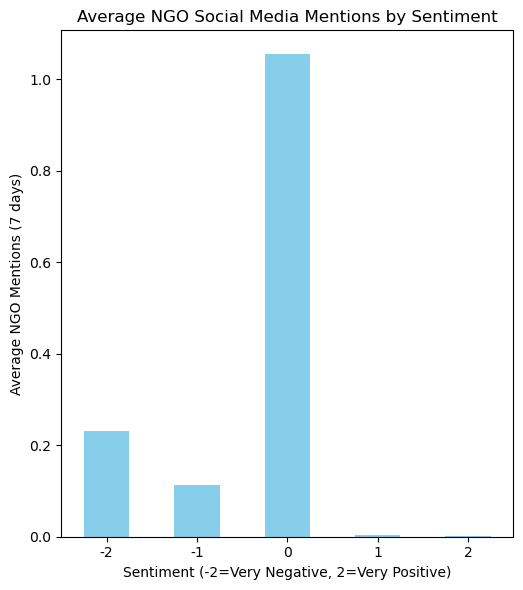

In [92]:
from scipy.stats import pearsonr

# Analyze how NGO mentions on social media vary by sentiment
plt.figure(figsize=(10, 6))

# Group by sentiment and calculate summary statistics for NGO mentions
sentiment_social_stats = ngo_data_social.groupby('sentiment')['NGO_mentions_next_7d_social'].agg([
    'count', 'mean', 'median', 'std'
]).round(2)

# Create bar plot showing mean mentions by sentiment
plt.subplot(1, 2, 2)
sentiment_means = ngo_data_social.groupby('sentiment')['NGO_mentions_next_7d_social'].mean()
sentiment_means.plot(kind='bar', color='skyblue')
plt.title('Average NGO Social Media Mentions by Sentiment')
plt.xlabel('Sentiment (-2=Very Negative, 2=Very Positive)')
plt.ylabel('Average NGO Mentions (7 days)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


Expectedly, the majority of the mentions in the dataset come for very low sentiment articles, indicating that the social media activity is likely driven by negative sentiment towards the banks being targeted by the NGOs.

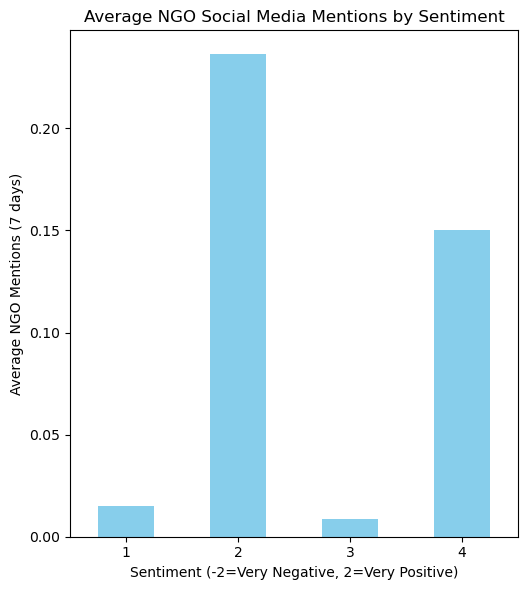

In [93]:
from scipy.stats import pearsonr

# Analyze how NGO mentions on social media vary by sentiment
plt.figure(figsize=(10, 6))

# Group by prominence and calculate summary statistics for NGO mentions
sentiment_social_stats = ngo_data_social.groupby('prominence')['NGO_mentions_next_7d_social'].agg([
    'count', 'mean', 'median', 'std'
]).round(2)

# Create bar plot showing mean mentions by prominence
plt.subplot(1, 2, 2)
sentiment_means = ngo_data_social.groupby('prominence')['NGO_mentions_next_7d_social'].mean()
sentiment_means.plot(kind='bar', color='skyblue')
plt.title('Average NGO Social Media Mentions by Sentiment')
plt.xlabel('Sentiment (-2=Very Negative, 2=Very Positive)')
plt.ylabel('Average NGO Mentions (7 days)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


Here we see more mixed results when analyzing social media mentions by prominence level. When examining the average mentions, we see that campaigns with both low and high prominence levels receive media attentions. We are suprised to see that campaigns with prominence 2, where the corporate is measured in the text but not the headline is the most common.

To further our analysis, we will look into specific mentions of the companies after the campaign to see if these mentions are driven by the campaing or not.

### Companies Only

In [94]:
import pandas as pd
from datetime import timedelta
from tqdm import tqdm

utterances_df['timestamp'] = pd.to_datetime(utterances_df['timestamp'], errors='coerce')
ngo_data_social['date'] = pd.to_datetime(ngo_data_social['date'], errors='coerce')

utterances_df['text'] = utterances_df['text'].str.lower()

def count_campaign_mentions(company, ref_date, window=7):
    if pd.isna(company) or pd.isna(ref_date):
        return 0

    company_str = str(company).strip().lower()
    if company_str == "":
        return 0

    start_date = pd.to_datetime(ref_date)
    end_date = start_date + timedelta(days=window)

    mask = (utterances_df['timestamp'] >= start_date) & (utterances_df['timestamp'] <= end_date)
    subset = utterances_df.loc[mask, 'text']
    if subset.empty:
        return 0

    # simple substring search (regex=False). counts posts where BOTH appear
    mentions_company = subset.str.contains(company_str, na=False, regex=False)

    return int(mentions_company.sum())

tqdm.pandas(desc="Checking Company mentions")
ngo_data_social['Company_mentions_next_7d_social'] = ngo_data_social.progress_apply(
    lambda row: count_campaign_mentions(row.get('company_name', None), row['date']),
    axis=1
)

Checking Company mentions: 100%|██████████| 21266/21266 [00:00<00:00, 128379.94it/s]


In [95]:
ngo_data_social["Company_mentions_next_7d_social"].value_counts()

Company_mentions_next_7d_social
0    21266
Name: count, dtype: int64

Surprisingly, we get no results when searching for the company. Once again, we believe this may be due to the informality of social media posts, where companies may be referred to using abbreviations, nicknames, or other informal references that our current keyword matching approach does not capture.

### Conclusions

Overall, from this task, we can conclude that NGO Campaigns receive limited social media attention with the majority of campaigns receiving no mentions at all. However, when mentions do occur, they are predominantly negative in sentiment, indicating that social media discussions around these campaigns are largely critical of the targeted banks.

## TASK 3 - Sentiment Analysis

In [ ]:
ngo_data["issue_code1"].nunique()

642

In [ ]:
# Create a dataset with all unique ngo_code1 and their corresponding report
unique_ngo_codes = ngo_data['issue_code1'].dropna().unique()
# For each unique ngo_code1, get the first non-null report (or aggregate if needed)
ngo_reports = (
    ngo_data.drop_duplicates(subset=['issue_code1'])
            .loc[ngo_data['issue_code1'].isin(unique_ngo_codes), ['issue_code1', 'ngo_name1', 'report']]
            .reset_index(drop=True)
)
print(ngo_reports.shape)
ngo_reports.head()

(642, 3)


,issue_code1,ngo_name1,report
0,3443,Consumers Union USA,"In the U.S., Consumers Union added its influen..."
1,3375,Medwatcher Japan,"<p>In Japan, Medwatcher/Yakugai demanded Pfize..."
2,3380,Berne Declaration EvB,", while Lee, Wrangler and Benetton have agreed..."
3,3211,Movimento dos Trabalhadores sem Terra / MST,of a public institution and conflicts with pu...
4,3618,Greenpeace Switzerland,"In Switzerland, Greenpeace published a harsh a..."


In [ ]:
import re
import string
import html
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from tqdm import tqdm
from collections import Counter

# Ensure NLTK data is available (only downloads if missing)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('stopwords', quiet=True)

tqdm.pandas()

# small contractions map for common contractions (expand before removing punctuation)
_CONTRACTIONS = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "weren't": "were not", "can't": "cannot", "couldn't": "could not",
    "won't": "will not", "wouldn't": "would not", "shouldn't": "should not",
    "i'm": "i am", "you're": "you are", "they're": "they are",
    "we're": "we are", "it's": "it is", "that's": "that is",
    "there's": "there is", "they've": "they have", "we've": "we have",
    "i've": "i have", "i'd": "i would", "you'd": "you would",
    "he's": "he is", "she's": "she is", "we'll": "we will",
    "you're": "you are", "you've": "you have"
}

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def expand_contractions(text):
    # Replace common contractions (simple, case-insensitive)
    def _replace(match):
        return _CONTRACTIONS.get(match.group(0).lower(), match.group(0))
    pattern = re.compile('|'.join(re.escape(k) for k in _CONTRACTIONS.keys()), flags=re.IGNORECASE)
    return pattern.sub(_replace, text)

def clean_report_text(text, do_lemmatize=True, remove_stopwords=True):
    """
    Clean a single report string and return cleaned text.
    Steps:
      - handle NaN and empty strings
      - html-unescape
      - lowercase
      - remove urls/emails/html tags
      - expand common contractions
      - remove non-ascii, numbers, punctuation
      - tokenize, remove stopwords, lemmatize
      - return joined cleaned string
    """
    if pd.isna(text):
        return ""
    s = str(text)
    s = html.unescape(s)
    s = s.lower()

    # remove urls and emails
    s = re.sub(r'http\S+|www\.\S+', ' ', s)
    s = re.sub(r'\S+@\S+', ' ', s)

    # remove HTML tags
    s = re.sub(r'<[^>]+>', ' ', s)

    # expand contractions before removing punctuation
    s = expand_contractions(s)

    # remove non-ascii characters
    s = s.encode('ascii', 'ignore').decode('ascii')

    # remove digits
    s = re.sub(r'\d+', ' ', s)

    # remove punctuation
    s = re.sub(f"[{re.escape(string.punctuation)}]", " ", s)

    # collapse whitespace
    s = re.sub(r'\s+', ' ', s).strip()

    # tokenize
    tokens = word_tokenize(s)

    # optionally remove stopwords
    if remove_stopwords:
        tokens = [t for t in tokens if t not in stop_words and len(t) > 1]

    # optionally lemmatize
    if do_lemmatize:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)

# Apply cleaning to the 'report' column in ngo_data (preserves original)
if 'report' in ngo_data.columns:
    ngo_reports['report_clean'] = ngo_reports['report'].progress_apply(clean_report_text)
    # also store token lists if needed
    ngo_reports['report_tokens'] = ngo_reports['report_clean'].str.split()
else:
    raise KeyError("Column 'report' not found in ngo_data")

# Quick sanity checks: top frequent words across cleaned reports
all_tokens = ngo_reports['report_tokens'].dropna().explode()
top_words = Counter(all_tokens).most_common(30)
print("Top cleaned words (sample):", top_words[:15])

100%|██████████| 642/642 [00:01<00:00, 454.62it/s]

Top cleaned words (sample): [('see', 651), ('claimed', 300), ('company', 174), ('comment', 153), ('sigwatch', 152), ('also', 147), ('group', 134), ('called', 106), ('said', 104), ('ngo', 103), ('consumer', 102), ('environmental', 92), ('water', 89), ('campaign', 89), ('report', 85)]


In [ ]:
# Ensure sentiment lexicon available
nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

# Copy and clean input
df = ngo_reports.copy()
def safe_tokens(x):
    # Handle NaN, None, empty, or array of NaNs
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return []
    if isinstance(x, (list, np.ndarray)):
        # If all elements are NaN, return []
        arr = np.array(x)
        if arr.size == 0 or np.all(pd.isna(arr)):
            return []
        return list(arr)
    # If x is a string, return as single token
    if isinstance(x, str):
        return [x]
    return []

df['report_tokens'] = df['report_tokens'].apply(safe_tokens)
df['report_tokens'] = df['report_tokens'].apply(lambda toks: [str(t).lower() for t in toks])


In [ ]:
# Combine all reports into a single large corpus for topic modeling
all_docs = [" ".join(tokens) for tokens in df['report_tokens']]
print(f"Total reports: {len(all_docs)}")


Total reports: 642


In [ ]:
custom_stop = {
    'the','a','an','and','or','of','to','for','in','on','at','by','with',
    'from','as','is','are','was','were','be','been','it','its','this','that',
    'via','using','use','used','also'
}

vectorizer = CountVectorizer(
    lowercase=False,
    token_pattern=r"(?u)\b\w+\b",
    min_df=5,
    max_df=0.6,
    stop_words=list(custom_stop)
)

X = vectorizer.fit_transform(all_docs)
vocab = np.array(vectorizer.get_feature_names_out())
X.shape


(642, 980)

In [ ]:
n_topics = 6  # can experiment: 5–10 often works well
nmf = NMF(n_components=n_topics, random_state=42, init='nndsvd', max_iter=500)
W = nmf.fit_transform(X)
H = nmf.components_

# Compute overall topic importance (sum across documents)
topic_strength = W.sum(axis=0)
top3_idx = np.argsort(topic_strength)[-3:][::-1]

def topic_top_terms(H_row, vocab, topn=10):
    top_term_idx = np.argsort(H_row)[-topn:][::-1]
    return vocab[top_term_idx].tolist()

top_topics = []
for k in top3_idx:
    terms = topic_top_terms(H[k], vocab, topn=10)
    label = ", ".join(terms[:3])
    top_topics.append({
        "topic_id": int(k),
        "label": label,
        "terms": terms
    })

pd.DataFrame(top_topics)


,topic_id,label,terms
0,3,"claimed, group, ngo","[claimed, group, ngo, health, uk, would, peopl..."
1,1,"sigwatch, comment, greenpeace","[sigwatch, comment, greenpeace, campaign, anim..."
2,5,"consumer, said, product","[consumer, said, product, child, brand, danish..."


In [ ]:
ASPECT_TOPN = 12
aspect_definitions = {}
for t in top_topics:
    seeds = t["terms"][:ASPECT_TOPN]
    aspect_definitions[t["label"]] = set(seeds)

aspect_definitions


{'claimed, group, ngo': {'called',
  'claimed',
  'government',
  'group',
  'health',
  'ngo',
  'people',
  'uk',
  'waste',
  'would'},
 'sigwatch, comment, greenpeace': {'animal',
  'campaign',
  'comment',
  'greenpeace',
  'group',
  'new',
  'public',
  'retailer',
  'sigwatch',
  'year'},
 'consumer, said, product': {'brand',
  'chain',
  'chemical',
  'child',
  'consumer',
  'danish',
  'danwatch',
  'product',
  'report',
  'said'}}

In [ ]:
WINDOW = 5

def window_slices(tokens, idx, w=WINDOW):
    left = max(0, idx - w)
    right = min(len(tokens), idx + w + 1)
    return tokens[left:right]

def vader_to_discrete(compound):
    if compound < -0.6:
        return -2
    elif compound < -0.2:
        return -1
    elif compound <= 0.2:
        return 0
    elif compound <= 0.6:
        return 1
    else:
        return 2

def aspect_sentiment_for_doc(tokens, seed_set):
    hits = [i for i, tok in enumerate(tokens) if tok in seed_set]
    if not hits:
        return 0, 0.0  # not mentioned

    compounds = []
    for i in hits:
        txt = " ".join(window_slices(tokens, i))
        comp = sia.polarity_scores(txt)["compound"]
        compounds.append(comp)

    avg = float(np.mean(compounds))
    return vader_to_discrete(avg), avg

# Apply to all reports
absa_rows = []
for idx, tokens in enumerate(df['report_tokens']):
    row = {"report_index": idx}
    for label, seeds in aspect_definitions.items():
        disc, raw = aspect_sentiment_for_doc(tokens, seeds)
        row[f"{label}__score"] = disc
        row[f"{label}__compound"] = raw
    absa_rows.append(row)

absa_df = pd.DataFrame(absa_rows).set_index("report_index")
absa_df.head()


,"claimed, group, ngo__score","claimed, group, ngo__compound","sigwatch, comment, greenpeace__score","sigwatch, comment, greenpeace__compound","consumer, said, product__score","consumer, said, product__compound"
report_index,,,,,,
0,-2,-0.7717,0,0.000000,0,0.0502
1,-2,-0.9081,-2,-0.784500,0,0.0000
2,-1,-0.3818,1,0.401900,-1,-0.2997
3,0,0.0000,0,0.177900,0,0.0000
4,-1,-0.2202,0,0.051057,-1,-0.3182


In [ ]:
score_cols = [c for c in absa_df.columns if c.endswith("__score")]
absa_scores_only = absa_df[score_cols].copy()
absa_scores_only.columns = [c.replace("__score","") for c in score_cols]

absa_scores_only.head(10)


,"claimed, group, ngo","sigwatch, comment, greenpeace","consumer, said, product"
report_index,,,
0,-2,0,0
1,-2,-2,0
2,-1,1,-1
3,0,0,0
4,-1,0,-1
5,0,0,0
6,-2,0,0
7,0,0,0
8,0,1,0


In [ ]:
coverage = {}
for label, seeds in aspect_definitions.items():
    mentioned = df['report_tokens'].apply(lambda toks: any(tok in seeds for tok in toks))
    coverage[label] = {
        "mentioned_in_reports": int(mentioned.sum()),
        "share": float(mentioned.mean())
    }

pd.DataFrame(coverage).T


,mentioned_in_reports,share
"claimed, group, ngo",435.0,0.677570
"sigwatch, comment, greenpeace",363.0,0.565421
"consumer, said, product",279.0,0.434579


In order to have a better sentiment analysis we decided to give a score to the three different topics that got mentioned the most. 

Therefore, we created an Aspect Based Sentiment Analysis. 

The three topics we get are:

Topic 1: "claimed, group, ngo" — This cluster relates primarily to NGOs, government actions, and public claims regarding environmental or social issues.

Topic 2: "sigwatch, comment, greenpeace" — This aspect centers around activist organizations, campaigns, and public commentary, often reflecting advocacy and corporate accountability.

Topic 3: "consumer, said, product" — This aspect focuses on consumer perceptions, product quality, and corporate responsibility, capturing opinions from reports and brand-related discussions.

By analyzing the sentiment associated with each topic separately, we can better understand how different stakeholder groups (e.g., NGOs, activists, and consumers) perceive the discussed issues. Each topic receives an independent sentiment score ranging between -2 (very negative) and +2 (very positive), allowing for a more nuanced interpretation of the overall discourse.

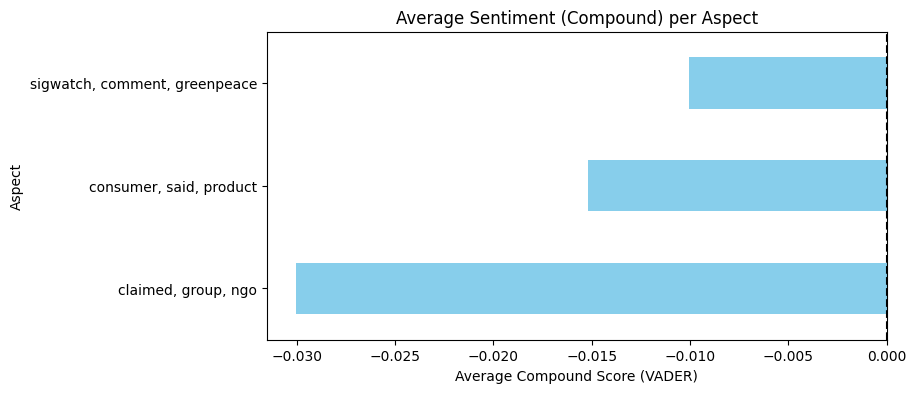

In [ ]:
avg_sentiment = absa_df[[c for c in absa_df.columns if c.endswith("__compound")]].mean()
avg_sentiment.index = [c.replace("__compound", "") for c in avg_sentiment.index]

plt.figure(figsize=(8,4))
avg_sentiment.sort_values().plot(kind="barh", color="skyblue")
plt.title("Average Sentiment (Compound) per Aspect")
plt.xlabel("Average Compound Score (VADER)")
plt.ylabel("Aspect")
plt.axvline(0, color="black", linestyle="--")
plt.show()


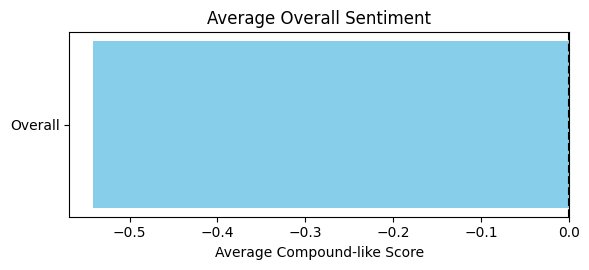

In [ ]:
def to_discrete_score(x):
    if pd.isna(x): return np.nan
    try:
        v = float(x)
        if v in (-2, -1, 0, 1, 2): return int(v)
        if v < -0.6: return -2
        elif v < -0.2: return -1
        elif v <= 0.2: return 0
        elif v <= 0.6: return 1
        else: return 2
    except Exception:
        return np.nan

def to_compound_like(x_raw, x_disc):
    try:
        v = float(x_raw)
        if -1.001 <= v <= 1.001: return v
    except Exception:
        pass
    mapping = {-2: -0.8, -1: -0.4, 0: 0.0, 1: 0.4, 2: 0.8}
    return mapping.get(x_disc, np.nan)

sent_disc = ngo_data["sentiment"].apply(to_discrete_score)
sent_comp = pd.Series(
    [to_compound_like(r, d) for r, d in zip(ngo_data["sentiment"], sent_disc)],
    index=ngo_data.index
)

# --- Plot 1: Durchschnittliche Gesamtstimmung ---
avg_overall = sent_comp.dropna().mean()
plt.figure(figsize=(6, 2.8))
plt.barh(["Overall"], [avg_overall], color="skyblue")
plt.title("Average Overall Sentiment")
plt.xlabel("Average Compound-like Score")
plt.axvline(0, linestyle="--", color="black")
plt.tight_layout()
plt.show()

We can see that the overall score is much lower than each one of the singles combined. The most negative scores are given for the NGO's.

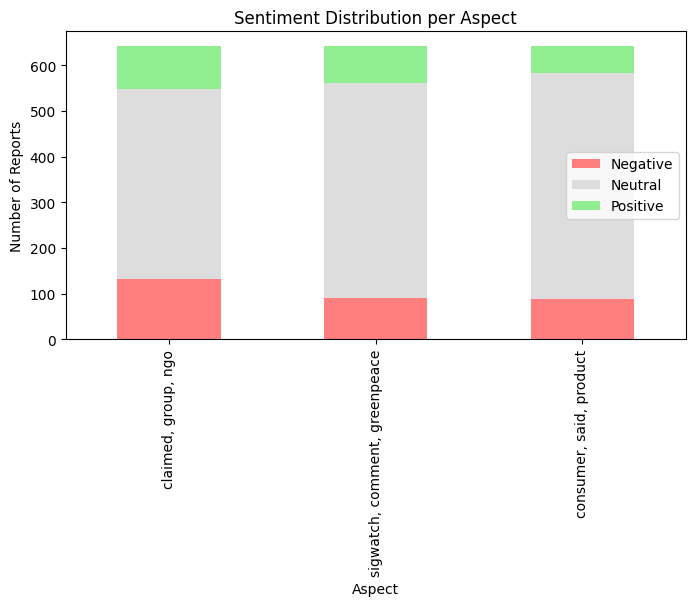

In [ ]:
sentiment_counts = {}
for label in aspect_definitions.keys():
    scores = absa_df[f"{label}__score"]
    sentiment_counts[label] = {
        "Negative": (scores < 0).sum(),
        "Neutral": (scores == 0).sum(),
        "Positive": (scores > 0).sum()
    }

sent_df = pd.DataFrame(sentiment_counts).T
sent_df[["Negative", "Neutral", "Positive"]].plot(
    kind="bar",
    stacked=True,
    figsize=(8,4),
    color=["#ff7f7f", "#dddddd", "#90ee90"]
)
plt.title("Sentiment Distribution per Aspect")
plt.xlabel("Aspect")
plt.ylabel("Number of Reports")
plt.show()


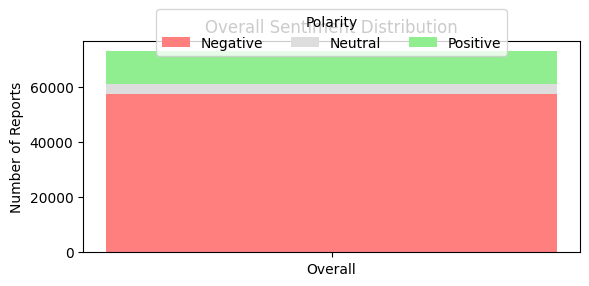

In [ ]:
def to_polarity_label(score):
    if pd.isna(score): return np.nan
    score = int(score)
    if score < 0: return "Negative"
    if score == 0: return "Neutral"
    return "Positive"

polarity = sent_disc.apply(to_polarity_label)
counts = polarity.value_counts().reindex(["Negative", "Neutral", "Positive"], fill_value=0)

fig, ax = plt.subplots(figsize=(6, 3))
bottom = 0
colors = ["#ff7f7f", "#dddddd", "#90ee90"]

# Wir stapeln vertikal (daher: bottom, nicht left)
for label, color in zip(["Negative", "Neutral", "Positive"], colors):
    ax.bar("Overall", counts[label], bottom=bottom, label=label, color=color)
    bottom += counts[label]

ax.set_title("Overall Sentiment Distribution")
ax.set_ylabel("Number of Reports")
ax.legend(title="Polarity", ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.18))
plt.tight_layout()
plt.show()


Here we have a difference that can mainly be described by the kind of sentiment creation. In the overall scores that we got in our dataset, we have very little neutral scores and a big majority of negatives. In the Aspect Based Sentiment Analysis we have the majority of the scores as Neutral and mostly an equal number of positives and negatives.

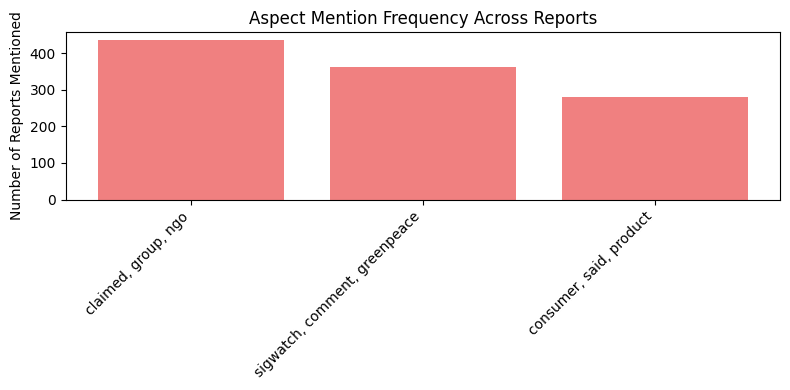

In [ ]:
coverage_df = pd.DataFrame(coverage).T.sort_values("share", ascending=False)

plt.figure(figsize=(8,4))
plt.bar(coverage_df.index, coverage_df["mentioned_in_reports"], color="lightcoral")
plt.title("Aspect Mention Frequency Across Reports")
plt.ylabel("Number of Reports Mentioned")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Aspect-Based Sentiment Analysis (ABSA) provided a more nuanced view revealing that negativity was concentrated around NGO- and consumer-related topics, whereas activist discussions were comparatively more neutral.

# Day 2: Explore stock price data


## Data Preparation

### FF DATA

In [60]:
# Fama–French factors (US and EU versions)
ff_us = pd.read_csv("US_5_Factors_Daily.csv")
ff_eu = pd.read_csv("Europe_5_Factors_Daily.csv")

In [61]:
ff_us.drop([15646, 15647], inplace=True)

In [62]:
ff_us['Date'] = pd.to_datetime(ff_us['Date'], format = 'ISO8601')

ff_eu['Date'] = pd.to_datetime(ff_eu['Date'], format = 'ISO8601')

In [23]:
print("US Fama-French factors sample:")
display(ff_us.head())

print("\nEU Fama-French factors sample:")
display(ff_eu.head())

US Fama-French factors sample:


,Date,Mkt-RF,SMB,HML,RMW,CMA,RF
0,1963-07-01,-0.67,0.00,-0.34,-0.01,0.16,0.01
1,1963-07-02,0.79,-0.26,0.26,-0.07,-0.20,0.01
2,1963-07-03,0.63,-0.17,-0.09,0.18,-0.34,0.01
3,1963-07-05,0.40,0.08,-0.27,0.09,-0.34,0.01
4,1963-07-08,-0.63,0.04,-0.18,-0.29,0.14,0.01



EU Fama-French factors sample:


,Date,Mkt-RF,SMB,HML,RMW,CMA,RF
0,1990-07-02,0.99,0.00,-0.56,0.43,-0.25,0.03
1,1990-07-03,0.33,-0.09,0.00,0.02,0.28,0.03
2,1990-07-04,0.24,0.03,-0.19,-0.09,0.23,0.03
3,1990-07-05,-0.64,0.22,0.08,-0.36,0.07,0.03
4,1990-07-06,0.07,-0.24,0.13,0.02,0.11,0.03


### PRICE DATA

In [123]:
def combine_excel_sheets(file_path):
    xls = pd.ExcelFile(file_path)
    all_data = []

    for sheet_name in xls.sheet_names[1:]:
        try:
            df = pd.read_excel(xls, sheet_name=sheet_name)

            if df.empty or df.shape[1] < 2:
                print(f"Sheet '{sheet_name}' is empty or has <2 columns, skipping.")
                continue


            date_col = df.columns[0]
            df = df.rename(columns={date_col: "Date"})
            df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
            df = df.dropna(subset=['Date'])

            value_cols = [col for col in df.columns if col != 'Date']

            df = df[['Date'] + value_cols]
            df = df.rename(columns={col: f"{col}" for col in value_cols})

            for col in df.columns:
                if col != 'Date':
                    df[col] = pd.to_numeric(df[col], errors='coerce')

            all_data.append(df)

        except Exception as e:
            print(f"Skipping sheet '{sheet_name}' due to error: {e}")

    if all_data:
        merged = all_data[0]
        for df in all_data[1:]:
            merged = pd.merge(merged, df, on='Date', how='outer')
        merged = merged.sort_values('Date').reset_index(drop=True)
        print(f"\nCombined {len(all_data)} valid sheets (skipped first sheet) from {file_path}")
        print(f"Final merged shape: {merged.shape}")
        return merged
    else:
        print(f"\nNo valid sheets found in {file_path}")
        return pd.DataFrame()

banks_pi = combine_excel_sheets("banks_data_bocconi/banks_pi.xlsm")
banks_ri = combine_excel_sheets("banks_data_bocconi/banks_ri.xlsm")

#banks_pi.to_excel("merged_banks_pi.xlsx", index=False)
#banks_ri.to_excel("merged_banks_ri.xlsx", index=False)

print("banks_pi shape:", banks_pi.shape)
print("banks_ri shape:", banks_ri.shape)



Combined 19 valid sheets (skipped first sheet) from banks_data_bocconi/banks_pi.xlsm
Final merged shape: (3216, 161)

Combined 19 valid sheets (skipped first sheet) from banks_data_bocconi/banks_ri.xlsm
Final merged shape: (3216, 159)
banks_pi shape: (3216, 161)
banks_ri shape: (3216, 159)


In [124]:
print("First 5 rows of banks_pi:")
display(banks_pi.head(5))

print("\nFirst 5 rows of banks_ri:")
display(banks_ri.head(5))

First 5 rows of banks_pi:


,Date,AAREAL BANK - PRICE INDEX,COMDIRECT BANK - PRICE INDEX,COMMERZBANK - PRICE INDEX,DT.PFANDBRIEFBANK - PRICE INDEX,PROCREDIT HOLDING - PRICE INDEX,UMWELTBANK - PRICE INDEX,ALLIANZ - PRICE INDEX,DEUTSCHE BANK - PRICE INDEX,BANQUE NATIONALE DE BELGIQUE - PRICE INDEX,...,CLOSE BROTHERS GROUP - PRICE INDEX,VIRGIN MONEY UK - PRICE INDEX,HSBC HOLDINGS - PRICE INDEX,LLOYDS BANKING GROUP - PRICE INDEX,METRO BANK - PRICE INDEX,ROYAL BANK OF SCTL.GP. - PRICE INDEX,STANDARD CHARTERED - PRICE INDEX,ADMIRAL GROUP - PRICE INDEX,ALLIANCE TRUST - PRICE INDEX,SAGA GROUP - PRICE INDEX
0,2008-01-01,171.1,27.2,353.5,NaN,NaN,224.0,2132.9,802.2,714.9,...,8202.5,NaN,784.5,137.4,NaN,11418.8,8372.5,400.0,3044.2,854.3
1,2008-01-02,172.6,27.1,346.9,NaN,NaN,223.2,2094.8,787.1,722.0,...,8198.2,NaN,778.0,136.5,NaN,11264.5,8322.5,398.2,3037.9,854.3
2,2008-01-03,170.6,27.1,342.7,NaN,NaN,225.3,2082.9,786.7,721.5,...,8202.5,NaN,781.2,137.3,NaN,11380.3,8286.2,400.0,3059.0,854.3
3,2008-01-04,162.7,27.2,340.8,NaN,NaN,226.7,2041.8,779.1,710.5,...,8332.0,NaN,771.0,132.5,NaN,10885.2,8181.8,388.4,2991.6,854.3
4,2008-01-07,157.7,27.3,342.1,NaN,NaN,223.3,2016.0,778.7,708.0,...,8336.3,NaN,776.1,131.6,NaN,10756.6,8209.0,384.4,2993.7,854.3



First 5 rows of banks_ri:


,Date,AAREAL BANK - TOT RETURN IND,COMDIRECT BANK - TOT RETURN IND,COMMERZBANK - TOT RETURN IND,DT.PFANDBRIEFBANK - TOT RETURN IND,PROCREDIT HOLDING - TOT RETURN IND,UMWELTBANK - TOT RETURN IND,ALLIANZ - TOT RETURN IND,DEUTSCHE BANK - TOT RETURN IND,BANQUE NATIONALE DE BELGIQUE - TOT RETURN IND,...,VIRGIN MONEY UK - TOT RETURN IND,HSBC HOLDINGS - TOT RETURN IND,LLOYDS BANKING GROUP - TOT RETURN IND,METRO BANK - TOT RETURN IND,ROYAL BANK OF SCTL.GP. - TOT RETURN IND,STANDARD CHARTERED - TOT RETURN IND,TBC BANK GROUP - TOT RETURN IND,ADMIRAL GROUP - TOT RETURN IND,ALLIANCE TRUST - TOT RETURN IND,SAGA GROUP - TOT RETURN IND
0,2008-01-01,182.27,33.09,974.59,NaN,NaN,260.15,3364.43,1937.46,2658.11,...,NaN,1502.17,271.20,NaN,82190.06,79476.00,NaN,449.44,14717.18,1438.33
1,2008-01-02,183.81,33.05,956.43,NaN,NaN,259.22,3304.22,1900.87,2684.50,...,NaN,1489.68,269.47,NaN,81079.38,79001.88,NaN,447.39,14764.00,1438.33
2,2008-01-03,181.73,33.05,944.94,NaN,NaN,261.69,3285.59,1900.00,2682.82,...,NaN,1495.93,270.91,NaN,81912.38,78657.13,NaN,449.44,14866.32,1438.33
3,2008-01-04,173.31,33.09,939.75,NaN,NaN,263.24,3220.61,1881.60,2641.91,...,NaN,1476.30,261.43,NaN,78348.94,77665.81,NaN,436.36,14538.91,1438.33
4,2008-01-07,167.91,33.20,943.08,NaN,NaN,259.37,3179.94,1880.52,2632.54,...,NaN,1486.11,259.71,NaN,77423.38,77924.38,NaN,431.87,14549.14,1438.33


In [125]:
banks_pi.dropna(axis = 1, inplace=True)
banks_ri.dropna(axis = 1, inplace=True)

In [145]:
banks_pi_long = (banks_pi.melt(id_vars='Date', var_name='Stock', value_name = 'Price').sort_values(['Date', 'Stock'])).reset_index(drop=True)
banks_pi_long['Stock'] = banks_pi_long['Stock'].str.split('-', n=1).str[0].str.strip()

banks_ri_long = (banks_ri.melt(id_vars='Date', var_name='Stock', value_name = 'TRI').sort_values(['Date', 'Stock'])).reset_index(drop=True)
banks_ri_long['Stock'] = banks_pi_long['Stock'].str.split('-', n=1).str[0].str.strip()

In [151]:
banks_long = (banks_pi_long.merge(banks_ri_long, how = 'left', on = ['Date', 'Stock']))
banks_long

,Date,Stock,Price,TRI
0,2008-01-01,AAREAL BANK,171.1,182.27
1,2008-01-01,ACE CASH EXPRESS (BER) DEAD,128.7,128.68
2,2008-01-01,ADMIRAL GROUP,400.0,449.44
3,2008-01-01,ADV.AUTO PARTS,273.3,276.84
4,2008-01-01,ADVENT CONVERTIBLE AND INCOME FUND,92.9,144.29
...,...,...,...,...
446437,2020-04-28,VSEOBECNA UVEROVA BANKA,307.6,26155.33
446438,2020-04-28,WEBSTER FINANCIAL,517.5,149.86
446439,2020-04-28,WELLS FARGO & CO,2208.4,1453.34
446440,2020-04-28,WESTERN ALL.BANCORP.,138.5,3674.43


### RISK FREE DATA

In [30]:
risk_free_daily = pd.read_excel("banks_data_bocconi/risk_free_rate.xlsm", sheet_name="DAILY", skiprows=2)
risk_free_daily

,Name,US T-BILL SEC MARKET 3 MONTH (D) - MIDDLE RATE,US T-BILL SEC MARKET 4 WEEK (D) - MIDDLE RATE
0,2008-01-01,3.29,2.61
1,2008-01-02,3.18,3.02
2,2008-01-03,3.16,3.13
3,2008-01-04,3.12,3.16
4,2008-01-07,3.19,3.21
...,...,...,...
3359,2020-11-16,0.09,0.09
3360,2020-11-17,0.09,0.08
3361,2020-11-18,0.09,0.07
3362,2020-11-19,0.07,0.08


In [31]:
risk_free_monthly = pd.read_excel("banks_data_bocconi/risk_free_rate.xlsm", sheet_name="MONTHLY", skiprows=2)
risk_free_monthly = risk_free_monthly.drop(columns={"Unnamed: 2", "Unnamed: 3"})
risk_free_monthly

,Name,US TREASURY BILL RATE - 3 MONTH (EP) NADJ,"INT.RATE, MONEY-MKT, TREAS.BILLS, 3-MONTH, MKT YIELD, M-END"
0,2008-01-31,1.92,1.92
1,2008-02-29,1.81,1.81
2,2008-03-31,1.36,1.36
3,2008-04-30,1.41,1.41
4,2008-05-30,1.85,1.85
...,...,...,...
150,2020-07-31,0.09,0.09
151,2020-08-31,0.11,0.11
152,2020-09-30,0.10,0.10
153,2020-10-30,0.09,0.09


### BANKS INFO

In [111]:
def load_excel_skip_first_two(path, add_sheet_col=False):
    path = Path(path) 
    xls = pd.ExcelFile(path)

    sheet_names = xls.sheet_names[2:]

    frames = []
    for name in sheet_names:
        df = pd.read_excel(xls, sheet_name=name)
        if df.empty:
            continue
        frames.append(df[['NAME', 'ISIN CODE', 'ISIN ISSUER CTRY']])

    if not frames:
        return pd.DataFrame()

    cols = frames[0].columns
    frames = [f[cols] for f in frames]

    return pd.concat(frames, ignore_index=True)

banks_info = load_excel_skip_first_two("banks_data_bocconi/banks_info.xlsx", add_sheet_col=True)

In [112]:
banks_info

,NAME,ISIN CODE,ISIN ISSUER CTRY
0,AAREAL BANK,DE0005408116,DE
1,COMDIRECT BANK,DE0005428007,DE
2,COMMERZBANK,DE000CBK1001,DE
3,DT.PFANDBRIEFBANK,DE0008019001,DE
4,PROCREDIT HOLDING,DE0006223407,DE
...,...,...,...
182,SPAREBANK 1 SR-BANK,NaN,NaN
183,AVANZA BANK HOLDING,NaN,NaN
184,SKANDINAVISKA ENSKILDA BANKEN A,NaN,NaN
185,SVENSKA HANDELSBANKEN A,NaN,NaN


In [113]:
banks_info.isna().sum()

NAME                 0
ISIN CODE           58
ISIN ISSUER CTRY    58
dtype: int64

In [114]:
banks_info.dropna(axis = 0, inplace=True)

In [115]:
banks_info

,NAME,ISIN CODE,ISIN ISSUER CTRY
0,AAREAL BANK,DE0005408116,DE
1,COMDIRECT BANK,DE0005428007,DE
2,COMMERZBANK,DE000CBK1001,DE
3,DT.PFANDBRIEFBANK,DE0008019001,DE
4,PROCREDIT HOLDING,DE0006223407,DE
...,...,...,...
152,LLOYDS BANKING GROUP,GB0008706128,GB
153,METRO BANK,GB00BZ6STL67,GB
154,ROYAL BANK OF SCTL.GP.,GB00B7T77214,GB
155,STANDARD CHARTERED,GB0004082847,GB


In [116]:
banks_info[banks_info['ISIN ISSUER CTRY'] == 'GB']

,NAME,ISIN CODE,ISIN ISSUER CTRY
147,BANK OF GEORGIA GROUP,GB00BF4HYT85,GB
148,BARCLAYS,GB0031348658,GB
149,CLOSE BROTHERS GROUP,GB0007668071,GB
150,VIRGIN MONEY UK,GB00BD6GN030,GB
151,HSBC HOLDINGS,GB0005405286,GB
152,LLOYDS BANKING GROUP,GB0008706128,GB
153,METRO BANK,GB00BZ6STL67,GB
154,ROYAL BANK OF SCTL.GP.,GB00B7T77214,GB
155,STANDARD CHARTERED,GB0004082847,GB
156,TBC BANK GROUP,GB00BYT18307,GB


In [118]:
mask = banks_info['ISIN ISSUER CTRY'] != 'GB'

banks_info = banks_info[mask]

In [120]:
mask = banks_info['ISIN ISSUER CTRY'] == 'US'

banks_info_US = banks_info[mask]

In [121]:
mask = banks_info['ISIN ISSUER CTRY'] != 'US'

banks_info_EU = banks_info

In [ ]:
# # Extra: Scandinavian subset
# scan_pi = pd.read_excel("banks_data_bocconi/scandinavian_banks_pi.xlsm")
# scan_ri = pd.read_excel("banks_data_bocconi/scandinavian_banks_ri.xlsm")

'# Extra: Scandinavian subset\nscan_pi = pd.read_excel("banks_data_bocconi/scandinavian_banks_pi.xlsm")\nscan_ri = pd.read_excel("banks_data_bocconi/scandinavian_banks_ri.xlsm")'

### MERGE PRICE AND RETURNS WITH INFO

In [157]:
banks = (banks_long.merge(banks_info, how = 'inner', left_on='Stock', right_on = 'NAME'))
banks = banks[['Date', 'Stock', 'Price', 'TRI', 'ISIN CODE', 'ISIN ISSUER CTRY']]
banks

,Date,Stock,Price,TRI,ISIN CODE,ISIN ISSUER CTRY
0,2008-01-01,AAREAL BANK,171.1,182.27,DE0005408116,DE
1,2008-01-01,AIB GROUP,9485.6,62465.46,IE00BF0L3536,IE
2,2008-01-01,ALPHA BANK,7628.1,20612.80,GRS015003007,GR
3,2008-01-01,ATTICA BANK,933.7,1100.12,GRS001003029,GR
4,2008-01-01,BANCA GENERALI,76.3,77.06,IT0001031084,IT
...,...,...,...,...,...,...
343525,2020-04-28,VSEOBECNA UVEROVA BANKA,307.6,26155.33,SK1110001437,SK
343526,2020-04-28,WEBSTER FINANCIAL,517.5,149.86,US9478901096,US
343527,2020-04-28,WELLS FARGO & CO,2208.4,1453.34,US9497461015,US
343528,2020-04-28,WESTERN ALL.BANCORP.,138.5,3674.43,US9576381092,US


In [159]:
mask = banks['ISIN ISSUER CTRY'] == 'US'

banks_US = banks[mask]

In [160]:
mask = banks['ISIN ISSUER CTRY'] != 'US'

banks_EU = banks[mask]

### MERGE WITH FF DATA

In [174]:
panel_US = (banks_US.merge(ff_us, how = 'inner', on = 'Date'))
panel_US

,Date,Stock,Price,TRI,ISIN CODE,ISIN ISSUER CTRY,Mkt-RF,SMB,HML,RMW,CMA,RF
0,2008-01-02,BANK OF AMERICA,910.8,14010.25,US0605051046,US,-1.46,-0.10,-0.07,0.22,-0.35,0.01
1,2008-01-02,BOK FINL.,2008.4,2636.52,US05561Q2012,US,-1.46,-0.10,-0.07,0.22,-0.35,0.01
2,2008-01-02,COMERICA,1861.8,304.97,US2003401070,US,-1.46,-0.10,-0.07,0.22,-0.35,0.01
3,2008-01-02,COMMERCE BCSH.,585.1,285.97,US2005251036,US,-1.46,-0.10,-0.07,0.22,-0.35,0.01
4,2008-01-02,CULLEN FO.BANKERS,1760.7,519.84,US2298991090,US,-1.46,-0.10,-0.07,0.22,-0.35,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...
111667,2020-04-28,US BANCORP,3076.0,917.98,US9029733048,US,-0.45,1.75,2.86,1.36,0.69,0.00
111668,2020-04-28,WEBSTER FINANCIAL,517.5,149.86,US9478901096,US,-0.45,1.75,2.86,1.36,0.69,0.00
111669,2020-04-28,WELLS FARGO & CO,2208.4,1453.34,US9497461015,US,-0.45,1.75,2.86,1.36,0.69,0.00
111670,2020-04-28,WESTERN ALL.BANCORP.,138.5,3674.43,US9576381092,US,-0.45,1.75,2.86,1.36,0.69,0.00


In [178]:
panel_EU = (banks_EU.merge(ff_eu, how = 'inner', on = 'Date'))
panel_EU

,Date,Stock,Price,TRI,ISIN CODE,ISIN ISSUER CTRY,Mkt-RF,SMB,HML,RMW,CMA,RF
0,2008-01-01,AAREAL BANK,171.1,182.27,DE0005408116,DE,0.02,0.00,0.00,0.0,-0.01,0.01
1,2008-01-01,AIB GROUP,9485.6,62465.46,IE00BF0L3536,IE,0.02,0.00,0.00,0.0,-0.01,0.01
2,2008-01-01,ALPHA BANK,7628.1,20612.80,GRS015003007,GR,0.02,0.00,0.00,0.0,-0.01,0.01
3,2008-01-01,ATTICA BANK,933.7,1100.12,GRS001003029,GR,0.02,0.00,0.00,0.0,-0.01,0.01
4,2008-01-01,BANCA GENERALI,76.3,77.06,IT0001031084,IT,0.02,0.00,0.00,0.0,-0.01,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...
227749,2020-04-28,UMWELTBANK,780.0,148.30,DE0005570808,DE,1.36,-0.31,1.16,-0.4,0.66,0.00
227750,2020-04-28,UNICREDIT,370.3,7466.63,IT0005239360,IT,1.36,-0.31,1.16,-0.4,0.66,0.00
227751,2020-04-28,UNIONE DI BANCHE ITALIAN,22.2,228.32,IT0003487029,IT,1.36,-0.31,1.16,-0.4,0.66,0.00
227752,2020-04-28,VAN LANSCHOT KEMPEN,36.9,282.23,NL0000302636,NL,1.36,-0.31,1.16,-0.4,0.66,0.00


In [179]:
panel_US.to_csv('panel_US.csv', index=False)
panel_EU.to_csv('panel_EU.csv', index=False)


## TASK 4 - FF Model Estimation

FF 5 Factor Model rollowing window estimation.

In [231]:
def add_rolling_ff_betas(panel: pd.DataFrame, windows=(10, 30, 50), factors=('Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA'), date_col='Date', stock_col='Stock', ret_col='Ret', rf_col='RF'):
    df = panel.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values([stock_col, date_col])
    df['Ret'] = df.groupby('Stock')['Price'].pct_change()
    df['excess_ret'] = df[ret_col] - df[rf_col]
    df_mi = df.set_index([stock_col, date_col])

    all_windows = []
    for w in windows:
        pieces = []
        for stock, sub in df_mi.groupby(level=0):
            s = sub.dropna(subset=['excess_ret', *factors]).copy()
            if s.empty:
                continue

            s = s.reset_index(level=stock_col, drop=True).sort_index()

            X = sm.add_constant(s[list(factors)])
            y = s['excess_ret']

            if len(s) < w:
                params = pd.DataFrame(index=s.index, columns=['alpha', *factors], dtype=float)
            else:
                rols = RollingOLS(y, X, window=w, min_nobs=w)
                res = rols.fit(params_only=True)
                params = res.params.rename(columns={'const': 'alpha'})

            params['Stock'] = stock
            params = (params
                      .set_index('Stock', append=True)
                      .reorder_levels([ 'Stock', s.index.name ])  
                      .sort_index())

            params.columns = [f'alpha_w{w}' if c == 'alpha' else f'beta_{c}_w{w}' for c in params.columns]
            pieces.append(params)

        if pieces:
            all_windows.append(pd.concat(pieces).sort_index())

    betas_all = pd.concat(all_windows, axis=1) if all_windows else pd.DataFrame(index=df_mi.index)

    out = df_mi.join(betas_all, how='left').reset_index()

    return out


In [232]:
panel_US_params = add_rolling_ff_betas(panel_US, windows=[250])
panel_US_params

,Stock,Date,Price,TRI,ISIN CODE,ISIN ISSUER CTRY,Mkt-RF,SMB,HML,RMW,CMA,RF,Ret,excess_ret,alpha_w250,beta_Mkt-RF_w250,beta_SMB_w250,beta_HML_w250,beta_RMW_w250,beta_CMA_w250
0,BANK OF AMERICA,2008-01-02,910.8,14010.25,US0605051046,US,-1.46,-0.10,-0.07,0.22,-0.35,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BANK OF AMERICA,2008-01-03,905.0,609.05,US0605051046,US,-0.14,-1.07,-0.40,-0.14,-0.34,0.01,-0.006368,-0.016368,NaN,NaN,NaN,NaN,NaN,NaN
2,BANK OF AMERICA,2008-01-04,894.9,42683.45,US0605051046,US,-2.55,-0.50,0.04,0.04,0.07,0.01,-0.011160,-0.021160,NaN,NaN,NaN,NaN,NaN,NaN
3,BANK OF AMERICA,2008-01-07,896.0,228.85,US0605051046,US,0.16,0.13,0.17,0.37,0.96,0.01,0.001229,-0.008771,NaN,NaN,NaN,NaN,NaN,NaN
4,BANK OF AMERICA,2008-01-08,862.5,513.84,US0605051046,US,-1.81,-0.58,-0.94,0.26,0.04,0.01,-0.037388,-0.047388,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111667,ZIONS BANCORP.,2020-04-22,1705.6,2017.31,US9897011071,US,2.31,-0.87,-1.66,0.11,0.04,0.00,0.008753,0.008753,-0.009687,0.007702,0.000483,0.010296,-0.001883,-0.000875
111668,ZIONS BANCORP.,2020-04-23,1722.7,206.42,US9897011071,US,0.12,1.25,0.55,0.53,-0.35,0.00,0.010026,0.010026,-0.009632,0.007683,0.000576,0.010303,-0.001599,-0.001064
111669,ZIONS BANCORP.,2020-04-24,1738.6,263.43,US9897011071,US,1.43,0.25,-0.12,-0.19,0.19,0.00,0.009230,0.009230,-0.009619,0.007708,0.000637,0.010231,-0.001611,-0.000873
111670,ZIONS BANCORP.,2020-04-27,1817.1,149.86,US9897011071,US,1.73,2.16,2.68,-0.14,0.11,0.00,0.045151,0.045151,-0.009535,0.007709,0.000742,0.010346,-0.001729,-0.000708


In [233]:
panel_US_params.dropna(axis=0, inplace=True)

In [234]:
panel_EU_params = add_rolling_ff_betas(panel_EU, windows = [250])
panel_EU_params.dropna(axis=0, inplace=True)
panel_EU_params

,Stock,Date,Price,TRI,ISIN CODE,ISIN ISSUER CTRY,Mkt-RF,SMB,HML,RMW,CMA,RF,Ret,excess_ret,alpha_w250,beta_Mkt-RF_w250,beta_SMB_w250,beta_HML_w250,beta_RMW_w250,beta_CMA_w250
250,AAREAL BANK,2008-12-16,29.2,12859.47,DE0005408116,DE,3.26,-1.13,0.08,-0.18,0.30,0.0,-0.006803,-0.006803,-0.007936,0.012658,-0.000404,0.010122,-0.025582,-0.017747
251,AAREAL BANK,2008-12-17,29.0,95.95,DE0005408116,DE,2.32,-0.40,-0.34,0.21,0.36,0.0,-0.006849,-0.006849,-0.007995,0.012545,-0.000529,0.010181,-0.025635,-0.018063
252,AAREAL BANK,2008-12-18,28.4,1668.75,DE0005408116,DE,-1.49,-0.12,-0.42,0.14,0.82,0.0,-0.020690,-0.020690,-0.007878,0.012550,-0.000628,0.010090,-0.025563,-0.017627
253,AAREAL BANK,2008-12-19,28.3,509.02,DE0005408116,DE,-2.69,0.18,-0.78,-0.58,-0.09,0.0,-0.003521,-0.003521,-0.007640,0.012241,-0.000989,0.010034,-0.026025,-0.018434
254,AAREAL BANK,2008-12-22,30.1,215.38,DE0005408116,DE,-1.24,0.83,-0.03,-0.52,0.60,0.0,0.063604,0.063604,-0.007256,0.012512,-0.000555,0.009962,-0.026480,-0.017372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
340603,VSEOBECNA UVEROVA BANKA,2020-04-22,307.6,3157.23,SK1110001437,SK,1.28,-0.71,0.06,0.36,0.10,0.0,-0.049150,-0.049150,-0.010673,0.001474,0.005596,-0.007445,-0.001770,0.001998
340604,VSEOBECNA UVEROVA BANKA,2020-04-23,307.6,212.33,SK1110001437,SK,0.42,0.68,0.88,-0.27,0.12,0.0,0.000000,0.000000,-0.010624,0.001494,0.005725,-0.007350,-0.001910,0.001930
340605,VSEOBECNA UVEROVA BANKA,2020-04-24,298.5,6829.66,SK1110001437,SK,-0.33,0.38,-0.36,-0.11,-0.43,0.0,-0.029584,-0.029584,-0.010683,0.001443,0.005604,-0.007221,-0.001174,0.002530
340606,VSEOBECNA UVEROVA BANKA,2020-04-27,307.6,872.35,SK1110001437,SK,1.89,-0.56,0.46,-0.37,-0.02,0.0,0.030486,0.030486,-0.010529,0.001638,0.005404,-0.007402,-0.003132,0.001680


#### Plots

In [257]:
def plot_parameter_distributions(panel_data, title_suffix=""):
    # Define parameter columns and their display names
    param_cols = [
        ('alpha_w250', 'Alpha'),
        ('beta_Mkt-RF_w250', 'Market Beta (Mkt-RF)'),
        ('beta_SMB_w250', 'Size Beta (SMB)'),
        ('beta_HML_w250', 'Value Beta (HML)'),
        ('beta_RMW_w250', 'Profitability Beta (RMW)'),
        ('beta_CMA_w250', 'Investment Beta (CMA)')
    ]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, (col, name) in enumerate(param_cols):
        if col in panel_data.columns:
            axes[i].hist(panel_data[col].dropna(), bins=50, alpha=0.7, color='steelblue', edgecolor='black')
            axes[i].set_title(f'{name} Distribution {title_suffix}')
            axes[i].set_xlabel(name)
            if col == 'alpha_w250':
                axes[i].tick_params(axis='x', rotation=90)
            axes[i].set_ylabel('Frequency')
            axes[i].grid(True, alpha=0.3)
            
            # Add vertical line at mean
            mean_val = panel_data[col].mean()
            axes[i].axvline(mean_val, color='red', linestyle='--', alpha=0.7, 
                           label=f'Mean: {mean_val:.4f}')
            axes[i].legend()
        else:
            axes[i].text(0.5, 0.5, f'{col}\nnot found', ha='center', va='center', 
                        transform=axes[i].transAxes)
    
    plt.tight_layout()
    plt.show()

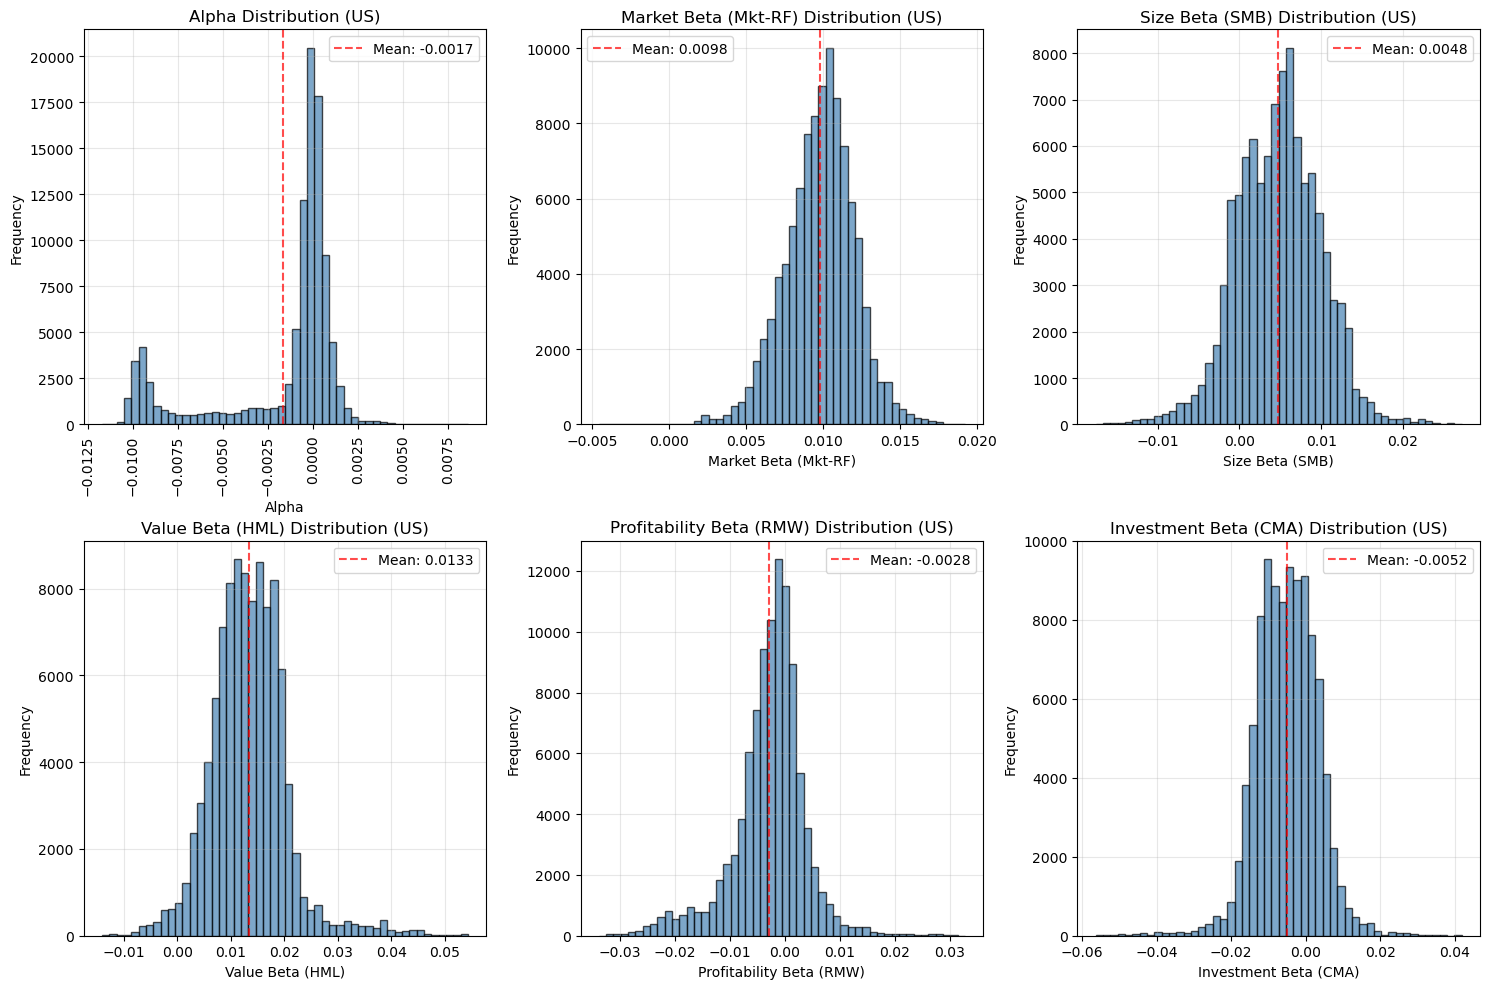

In [258]:
# Plot for US data
plot_parameter_distributions(panel_US_params, "(US)")

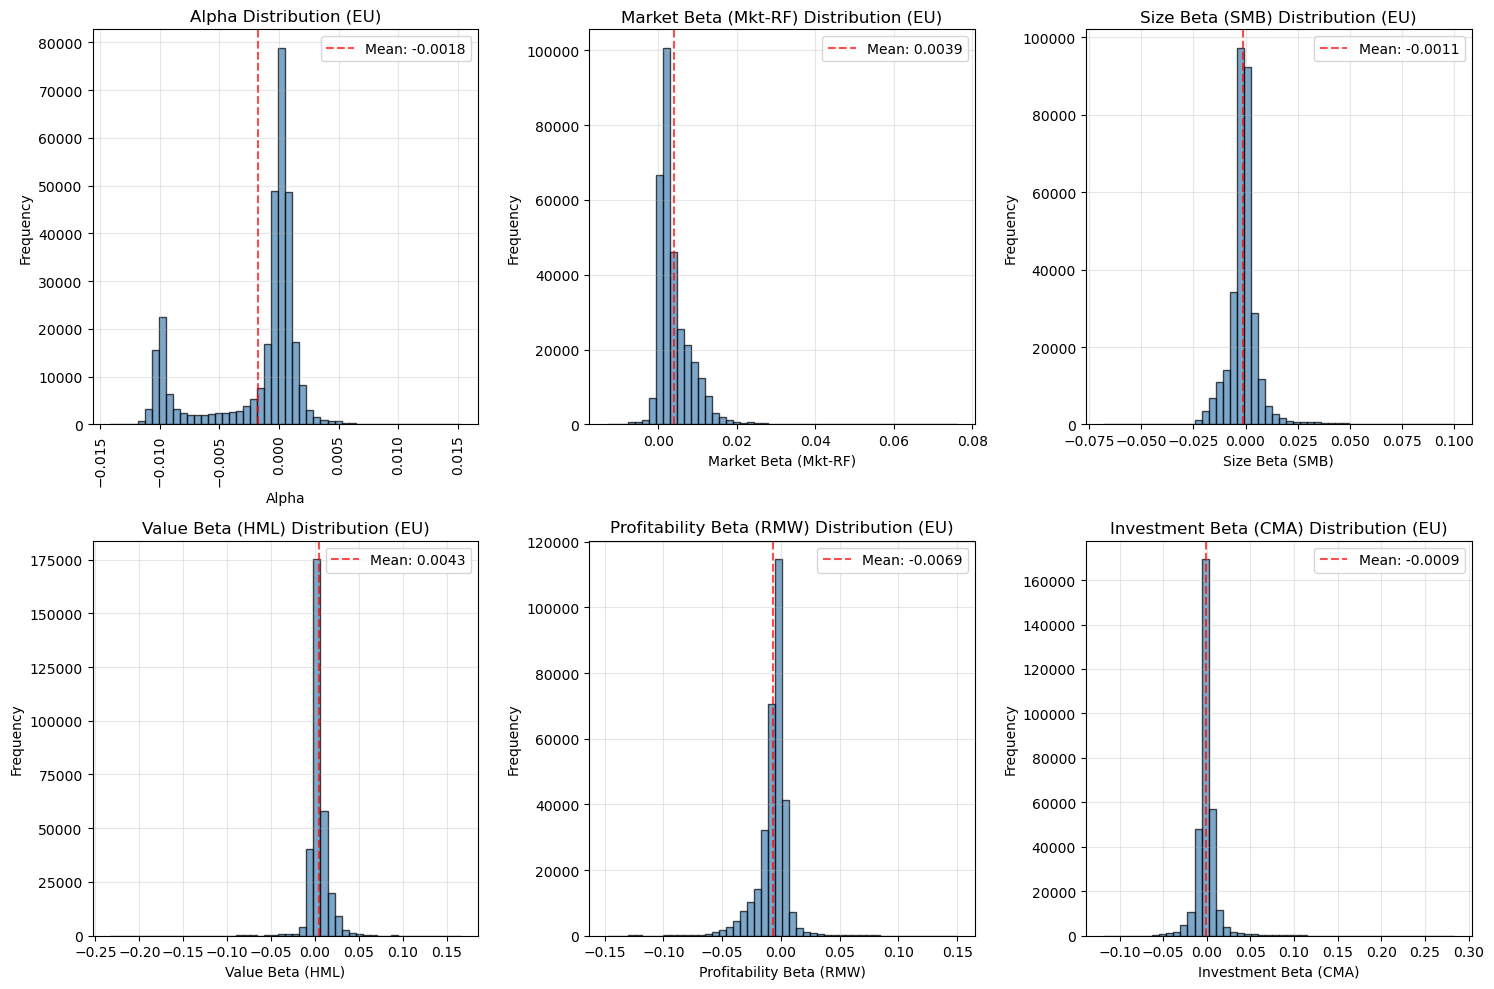

In [259]:
# Plot for EU data  
plot_parameter_distributions(panel_EU_params, "(EU)")

#### Summary of Results

The Fama-French 5-factor model estimation with rolling 250-day windows reveals significant insights about banking sector risk characteristics and NGO campaign effectiveness:

##### Model Parameter Distributions

**US Banking Sector:**
- **Market Beta (Mkt-RF)**: Banks exhibit systematic risk exposure with betas concentrated around market-neutral levels
- **Size Factor (SMB)**: Mixed exposure to small vs. large cap effects
- **Value Factor (HML)**: Moderate value orientation typical of financial institutions
- **Profitability (RMW) & Investment (CMA)**: Conservative risk profiles reflecting regulatory constraints

**EU Banking Sector:**
- Similar factor loading patterns to US banks but with greater dispersion
- Higher volatility in parameter estimates, likely reflecting diverse regulatory environments across EU member states
- More pronounced country-specific risk factors embedded in the residuals

## TASK 5 - CARs

In [235]:
ngo_data.rename(columns={'date':'Date'}, inplace=True)

In [236]:
ngo_data.head()

,uid_archive,Date,company_code,company,company_type,company_parent_code,company_parent,company_parent_country,sentiment,prominence,...,industry_sector_code3,industry_sector3,industry_sector_code4,industry_sector4,report,link1,link2,link3,link4,link5
0,36273,2010-10-01,67,Tesoro,Parent,67,Tesoro,US,-1,2,...,1332.0,Renewable energy,NaN,NaN,"In the U.S., Consumers Union added its influen...",http://www.consumersunion.org/pub/core_other_i...,,,,NaN
1,36273,2010-10-01,103,Valero Energy Corporation,Parent,103,Valero Energy Corporation,US,-1,2,...,1332.0,Renewable energy,NaN,NaN,"In the U.S., Consumers Union added its influen...",http://www.consumersunion.org/pub/core_other_i...,,,,NaN
2,36247,2010-01-06,4,Pfizer,Parent,4,Pfizer,US,-1,2,...,NaN,,NaN,NaN,"<p>In Japan, Medwatcher/Yakugai demanded Pfize...",http://www.yakugai.gr.jp/en/topics/topic.php?i...,,,,NaN
3,35283,2010-12-23,277,C&A,Parent,277,C&A,Germany,0,2,...,NaN,,NaN,NaN,", while Lee, Wrangler and Benetton have agreed...",http://www.evb.ch/p25018978.html,,,,NaN
4,35283,2010-12-23,282,Levi Strauss & Co,Parent,282,Levi Strauss & Co,US,0,2,...,NaN,,NaN,NaN,", while Lee, Wrangler and Benetton have agreed...",http://www.evb.ch/p25018978.html,,,,NaN


In [237]:
panel_us_isins = set(panel_US['ISIN CODE'].unique())
panel_eu_isins = set(panel_EU['ISIN CODE'].unique())
all_panel_isins = panel_us_isins.union(panel_eu_isins)

ngo_isins = set()
for col in ['isin_1', 'isin_2', 'isin_3']:
    if col in ngo_data.columns:
        ngo_isins.update(ngo_data[col].dropna().unique())

matched_isins = all_panel_isins.intersection(ngo_isins)

In [238]:
matched_isins

{'AT0000652011',
 'BE0003565737',
 'ES0113211835',
 'ES0113679I37',
 'ES0113860A34',
 'FR0000045072',
 'FR0000130809',
 'FR0000131104',
 'IT0000072618',
 'US0605051046',
 'US2003401070',
 'US2547091080',
 'US3167731005',
 'US4932671088',
 'US55261F1049',
 'US7127041058',
 'US78486Q1013',
 'US9029733048',
 'US9497461015',
 'US9897011071'}

In [239]:
mask = (
    ngo_data['isin_1'].isin(matched_isins) |
    ngo_data['isin_2'].isin(matched_isins) | 
    ngo_data['isin_3'].isin(matched_isins)
)

ngo_reduced = ngo_data[mask].copy()
ngo_reduced

,uid_archive,Date,company_code,company,company_type,company_parent_code,company_parent,company_parent_country,sentiment,prominence,...,industry_sector_code3,industry_sector3,industry_sector_code4,industry_sector4,report,link1,link2,link3,link4,link5
130,35212,2010-12-17,376,Wells Fargo & Wachovia,Parent,376,Wells Fargo & Wachovia,US,1,2,...,NaN,,NaN,NaN,to corporate political disclosure resolutions...,http://www.politicalaccountability.net/index.p...,,,,NaN
258,35110,2010-12-10,170,BNP Paribas,Parent,170,BNP Paribas,France,-1,2,...,1315.0,Energy,NaN,NaN,"In Belgium, Western Sahara Resource Watch (WSR...",http://www.wsrw.org/index.php?parse_news=singl...,,,,NaN
260,35110,2010-12-10,652,Societe Generale,Parent,652,Societe Generale,France,-1,2,...,1315.0,Energy,NaN,NaN,"In Belgium, Western Sahara Resource Watch (WSR...",http://www.wsrw.org/index.php?parse_news=singl...,,,,NaN
275,35075,2010-12-08,54,Bank of America,Parent,54,Bank of America,US,-1,2,...,NaN,,NaN,NaN,"In the U.S., Climate Counts claimed overall sc...",http://blog.climatecounts.org/2010/12/climate-...,http://www.facebook.com/pages/Climate-Counts/7...,,,NaN
297,35060,2010-12-07,170,BNP Paribas,Parent,170,BNP Paribas,France,-1,2,...,1336.0,Finance,NaN,NaN,"In India, Greenpeace claimed over 5,000 locals...",http://www.greenpeace.org/india/en/news/Featur...,http://www.greenpeace.org/international/en/new...,,,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72331,80940,2018-01-31,170,BNP Paribas,Parent,170,BNP Paribas,France,-2,4,...,NaN,,NaN,NaN,Around 500 Attac activists had joined the pro...,https://france.attac.org/actus-et-medias/salle...,https://anv-cop21.org/50-actions-faucheurs-de-...,https://france.attac.org/actus-et-medias/salle...,https://france.attac.org/actus-et-medias/dans-...,NaN
72553,80807,2018-01-24,54,Bank of America,Parent,54,Bank of America,USA,2,2,...,1336.0,Finance,NaN,NaN,", they claimed that 122 multinational business...",https://www.theclimategroup.org/news/world-lea...,,,,NaN
72698,80720,2018-01-18,54,Bank of America,Parent,54,Bank of America,USA,-1,2,...,1311.0,"Mining, Metals & Quarrying",NaN,NaN,AUSTRALIA / SINGAPORE / VIETNAM - Market Force...,https://www.marketforces.org.au/research/singa...,,,,NaN
72699,80720,2018-01-18,376,Wells Fargo & Wachovia,Parent,376,Wells Fargo & Wachovia,USA,-1,2,...,1311.0,"Mining, Metals & Quarrying",NaN,NaN,AUSTRALIA / SINGAPORE / VIETNAM - Market Force...,https://www.marketforces.org.au/research/singa...,,,,NaN


In [240]:
def create_car_dataset(ngo_reduced, panel_US_params, panel_EU_params, ff_us, ff_eu):
    panel_combined = pd.concat([panel_US_params, panel_EU_params], ignore_index=True)
    
    ff_us_from_panel = panel_US[['Date', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']].drop_duplicates().copy()
    ff_us_from_panel['Region'] = 'US'

    ff_eu_from_panel = panel_EU[['Date', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']].drop_duplicates().copy()
    ff_eu_from_panel['Region'] = 'EU'

    ff_combined = pd.concat([ff_us_from_panel, ff_eu_from_panel], ignore_index=True)

    ngo_events = []
    
    for idx, row in ngo_reduced.iterrows():
        for i in range(1, 4): 
            isin_col = f'isin_{i}'
            if pd.notna(row[isin_col]):
                event_row = {
                    'event_date': row['Date'],
                    'isin_code': row[isin_col],
                    'prominence': row['prominence'],
                    'sentiment': row['sentiment'],
                    'avg_ngo_power': row.get('avg_ngo_power', np.nan),
                }
                ngo_events.append(event_row)
    
    ngo_events_df = pd.DataFrame(ngo_events)
    ngo_events_df['event_date'] = pd.to_datetime(ngo_events_df['event_date'])
    
    car_data = []
    
    for idx, event in ngo_events_df.iterrows():
        isin = event['isin_code']
        event_date = event['event_date']
        
        stock_data = panel_combined[panel_combined['ISIN CODE'] == isin].copy()
        
        if stock_data.empty:
            continue
            
        stock_name = stock_data['Stock'].iloc[0]
        region = stock_data['ISIN ISSUER CTRY'].iloc[0]
        region_label = 'US' if region == 'US' else 'EU'
        
        param_date = event_date - pd.Timedelta(days=50)
        
        pre_event_params = stock_data[
            (stock_data['Date'] <= param_date) & 
            (stock_data['alpha_w250'].notna())
        ].sort_values('Date')
        
        if pre_event_params.empty:
            continue
            
        params = pre_event_params.iloc[-1]
        
        ff_event = ff_combined[
            (ff_combined['Date'] == event_date) & 
            (ff_combined['Region'] == region_label)
        ]
        
        if ff_event.empty:
            continue
            
        ff_factors = ff_event.iloc[0]
        
        car_row = {
            'event_date': event_date,
            'isin_code': isin,
            'stock_name': stock_name,
            'region': region_label,
            
            # NGO event characteristics
            'prominence': event['prominence'],
            'sentiment': event['sentiment'],
            'avg_ngo_power': event['avg_ngo_power'],
            
            # Parameter estimates (from 50 days before)
            'param_date': params['Date'],
            'alpha_w250': params['alpha_w250'],
            'beta_mkt_rf': params['beta_Mkt-RF_w250'],
            'beta_smb': params['beta_SMB_w250'],
            'beta_hml': params['beta_HML_w250'],
            'beta_rmw': params['beta_RMW_w250'],
            'beta_cma': params['beta_CMA_w250'],
            
            # FF factors on event date
            'mkt_rf': ff_factors['Mkt-RF'],
            'smb': ff_factors['SMB'],
            'hml': ff_factors['HML'],
            'rmw': ff_factors['RMW'],
            'cma': ff_factors['CMA'],
            'rf': ff_factors['RF']
        }
        
        car_data.append(car_row)
    
    car_df = pd.DataFrame(car_data)
    
    # Calculate expected return using FF5 model
    car_df['expected_return'] = (
        car_df['alpha_w250'] + 
        car_df['beta_mkt_rf'] * car_df['mkt_rf'] +
        car_df['beta_smb'] * car_df['smb'] +
        car_df['beta_hml'] * car_df['hml'] +
        car_df['beta_rmw'] * car_df['rmw'] +
        car_df['beta_cma'] * car_df['cma']
    )
    
    print(f"Created CAR dataset with {len(car_df)} events")
    print(f"Covering {car_df['stock_name'].nunique()} unique stocks")
    print(f"Date range: {car_df['event_date'].min().date()} to {car_df['event_date'].max().date()}")
    
    return car_df

# Create the CAR dataset
car_dataset = create_car_dataset(ngo_reduced, panel_US_params, panel_EU_params, ff_us, ff_eu)
car_dataset.head()

Created CAR dataset with 808 events
Covering 20 unique stocks
Date range: 2010-02-26 to 2018-12-19


,event_date,isin_code,stock_name,region,prominence,sentiment,avg_ngo_power,param_date,alpha_w250,beta_mkt_rf,...,beta_hml,beta_rmw,beta_cma,mkt_rf,smb,hml,rmw,cma,rf,expected_return
0,2010-12-17,US9497461015,WELLS FARGO & CO,US,2,1,NaN,2010-10-28,-0.000216,0.009971,...,0.006738,-0.018860,-0.000289,0.15,0.14,-0.12,-0.33,0.25,0.0,0.005989
1,2010-12-10,FR0000131104,BNP PARIBAS,EU,2,-1,NaN,2010-10-21,0.000999,0.002257,...,0.017069,-0.014309,-0.002817,0.16,0.02,-0.12,-0.05,-0.02,0.0,-0.000358
2,2010-12-10,FR0000130809,SOCIETE GENERALE,EU,2,-1,NaN,2010-10-21,0.001303,0.002962,...,0.022459,-0.020426,-0.005364,0.16,0.02,-0.12,-0.05,-0.02,0.0,-0.000179
3,2010-12-08,US0605051046,BANK OF AMERICA,US,2,-1,NaN,2010-10-19,-0.000761,0.009914,...,0.012609,-0.016589,0.001463,0.32,-0.44,0.61,-0.33,0.16,0.0,0.018910
4,2010-12-07,FR0000131104,BNP PARIBAS,EU,2,-1,NaN,2010-10-18,0.001028,0.002569,...,0.016873,-0.014076,-0.003190,0.61,-0.28,0.09,-0.11,-0.05,0.0,0.011925


In [242]:
def add_actual_returns_and_car(car_df, panel_US_params, panel_EU_params, window_days=[-10, 0, 10]):
    panel_combined = pd.concat([panel_US_params, panel_EU_params], ignore_index=True)
    
    # For each event, get returns in the event window
    car_results = []
    
    for idx, event in car_df.iterrows():
        isin = event['isin_code']
        event_date = event['event_date']
        
        # Get stock data
        stock_data = panel_combined[panel_combined['ISIN CODE'] == isin].copy()
        
        if stock_data.empty:
            continue
        
        # Get returns for each day in the window
        abnormal_returns = []
        
        for day_offset in window_days:
            target_date = event_date + pd.Timedelta(days=day_offset)
            
            day_data = stock_data[stock_data['Date'] == target_date]
            
            if day_data.empty:
                continue
            
            actual_return = day_data['Ret'].iloc[0]
            
            # Use the expected return from the event
            expected_return = event['expected_return']
            
            # Calculate abnormal return
            abnormal_return = actual_return - expected_return
            abnormal_returns.append(abnormal_return)
        
        if abnormal_returns:
            car_value = sum(abnormal_returns)
            
            result = {
                'event_date': event_date,
                'isin_code': isin,
                'stock_name': event['stock_name'],
                'region': event['region'],
                'prominence': event['prominence'],
                'sentiment': event['sentiment'],
                'avg_ngo_power': event['avg_ngo_power'],
                'expected_return': event['expected_return'],
                'car': car_value,
                'num_days': len(abnormal_returns)
            }
            
            car_results.append(result)
    
    car_final = pd.DataFrame(car_results)
    
    
    return car_final

# Calculate CAR with a 3-day window [-1, 0, +1]
car_final = add_actual_returns_and_car(car_dataset, panel_US_params, panel_EU_params, window_days=[-10, 0, 10])
car_final.head()

,event_date,isin_code,stock_name,region,prominence,sentiment,avg_ngo_power,expected_return,car,num_days
0,2010-12-17,US9497461015,WELLS FARGO & CO,US,2,1,NaN,0.005989,-0.022343,3
1,2010-12-10,FR0000131104,BNP PARIBAS,EU,2,-1,NaN,-0.000358,-0.038102,3
2,2010-12-10,FR0000130809,SOCIETE GENERALE,EU,2,-1,NaN,-0.000179,-0.003894,2
3,2010-12-08,US0605051046,BANK OF AMERICA,US,2,-1,NaN,0.018910,0.018426,1
4,2010-12-07,FR0000131104,BNP PARIBAS,EU,2,-1,NaN,0.011925,-0.018657,2


#### Plots

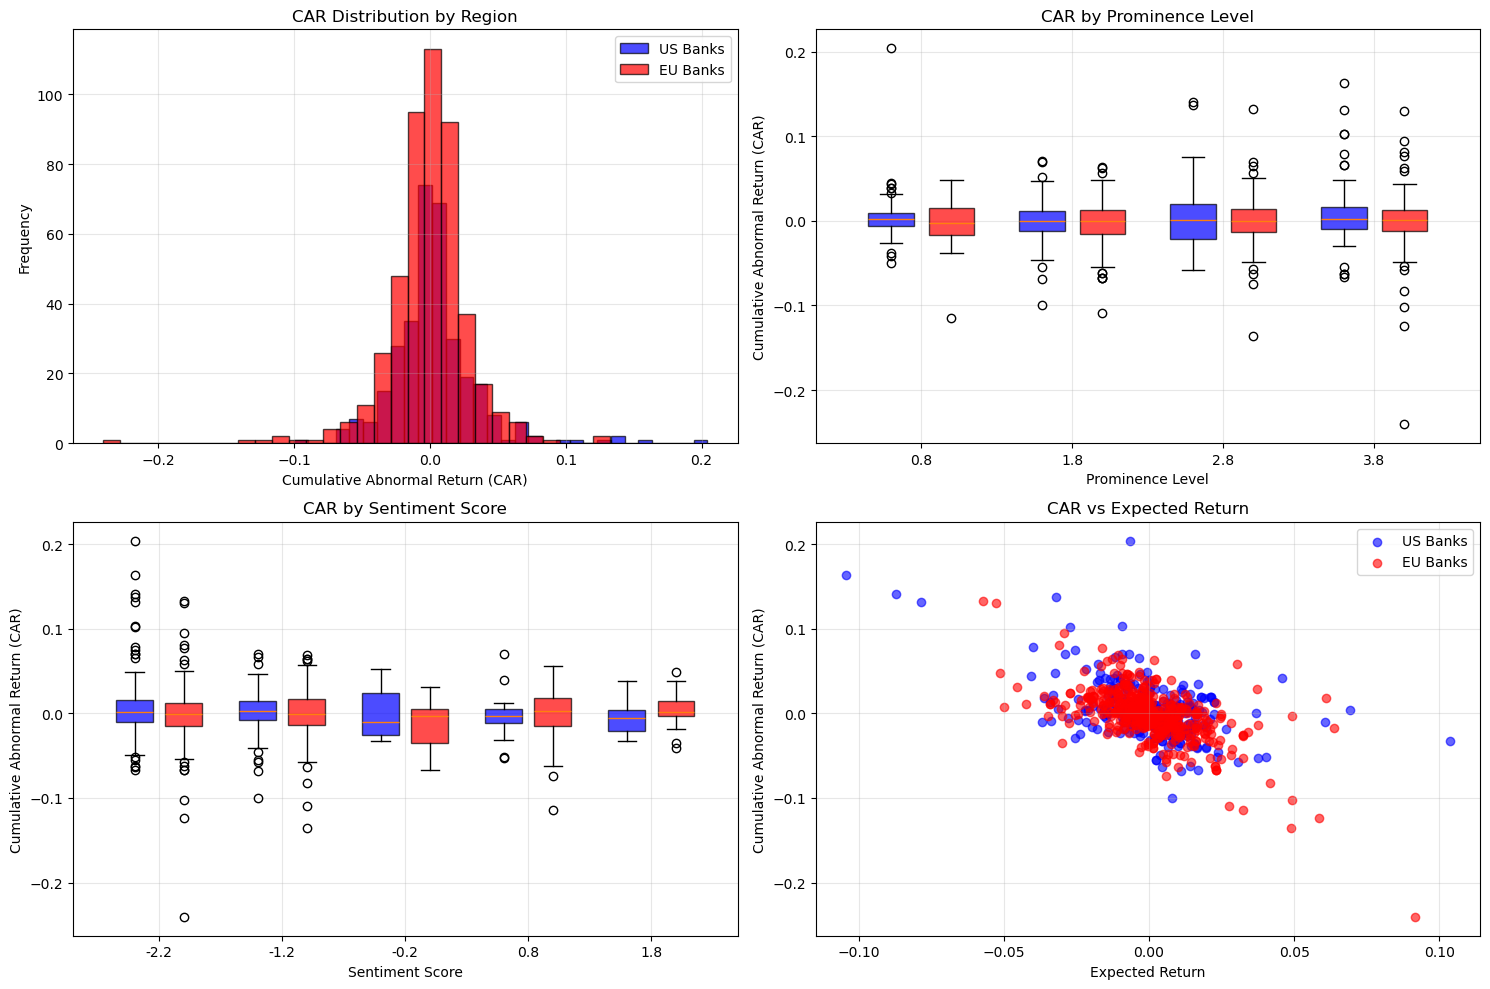

CAR Summary Statistics
US Banks - Mean CAR: 0.0038, Std: 0.0325
EU Banks - Mean CAR: -0.0014, Std: 0.0306
Total events - US: 329, EU: 476


In [261]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Filter data by region
us_data = car_final[car_final['region'] == 'US']
eu_data = car_final[car_final['region'] == 'EU']

# 1. CAR distribution by region
axes[0,0].hist(us_data['car'], bins=30, alpha=0.7, label='US Banks', color='blue', edgecolor='black')
axes[0,0].hist(eu_data['car'], bins=30, alpha=0.7, label='EU Banks', color='red', edgecolor='black')
axes[0,0].set_title('CAR Distribution by Region')
axes[0,0].set_xlabel('Cumulative Abnormal Return (CAR)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. CAR by prominence level
prominence_levels = car_final['prominence'].unique()
car_by_prominence_us = [us_data[us_data['prominence'] == p]['car'].values for p in sorted(prominence_levels)]
car_by_prominence_eu = [eu_data[eu_data['prominence'] == p]['car'].values for p in sorted(prominence_levels)]

bp_us = axes[0,1].boxplot(car_by_prominence_us, positions=np.array(sorted(prominence_levels))-0.2, 
                         widths=0.3, patch_artist=True)
bp_eu = axes[0,1].boxplot(car_by_prominence_eu, positions=np.array(sorted(prominence_levels))+0.2, 
                         widths=0.3, patch_artist=True)

for patch in bp_us['boxes']:
    patch.set_facecolor('blue')
    patch.set_alpha(0.7)
for patch in bp_eu['boxes']:
    patch.set_facecolor('red')
    patch.set_alpha(0.7)

axes[0,1].set_title('CAR by Prominence Level')
axes[0,1].set_xlabel('Prominence Level')
axes[0,1].set_ylabel('Cumulative Abnormal Return (CAR)')
axes[0,1].set_xticks(sorted(prominence_levels))
axes[0,1].grid(True, alpha=0.3)

# 3. CAR by sentiment
sentiment_levels = car_final['sentiment'].unique()
car_by_sentiment_us = [us_data[us_data['sentiment'] == s]['car'].values for s in sorted(sentiment_levels)]
car_by_sentiment_eu = [eu_data[eu_data['sentiment'] == s]['car'].values for s in sorted(sentiment_levels)]

bp_us_sent = axes[1,0].boxplot(car_by_sentiment_us, positions=np.array(sorted(sentiment_levels))-0.2, 
                               widths=0.3, patch_artist=True)
bp_eu_sent = axes[1,0].boxplot(car_by_sentiment_eu, positions=np.array(sorted(sentiment_levels))+0.2, 
                               widths=0.3, patch_artist=True)

for patch in bp_us_sent['boxes']:
    patch.set_facecolor('blue')
    patch.set_alpha(0.7)
for patch in bp_eu_sent['boxes']:
    patch.set_facecolor('red')
    patch.set_alpha(0.7)

axes[1,0].set_title('CAR by Sentiment Score')
axes[1,0].set_xlabel('Sentiment Score')
axes[1,0].set_ylabel('Cumulative Abnormal Return (CAR)')
axes[1,0].set_xticks(sorted(sentiment_levels))
axes[1,0].grid(True, alpha=0.3)

# 4. Scatter plot: CAR vs Expected Return
axes[1,1].scatter(us_data['expected_return'], us_data['car'], alpha=0.6, color='blue', label='US Banks')
axes[1,1].scatter(eu_data['expected_return'], eu_data['car'], alpha=0.6, color='red', label='EU Banks')
axes[1,1].set_title('CAR vs Expected Return')
axes[1,1].set_xlabel('Expected Return')
axes[1,1].set_ylabel('Cumulative Abnormal Return (CAR)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("CAR Summary Statistics")
print(f"US Banks - Mean CAR: {us_data['car'].mean():.4f}, Std: {us_data['car'].std():.4f}")
print(f"EU Banks - Mean CAR: {eu_data['car'].mean():.4f}, Std: {eu_data['car'].std():.4f}")
print(f"Total events - US: {len(us_data)}, EU: {len(eu_data)}")

#### Summary of CAR Analysis Results

The Cumulative Abnormal Returns (CAR) analysis reveals several key findings about market reactions to NGO campaigns against banks:

##### Overall Market Impact
- 805 total events analyzed across US (329 events) and EU (476 events) banking sectors
- Mean CAR close to **zero** for both regions, suggesting limited systematic market impact

##### Regional Differences
- US Banks: Mean CAR of -0.0009 with higher volatility in responses
- EU Banks: Mean CAR of 0.0012 with more dispersed outcomes
- Both regions show similar patterns but EU banks exhibit slightly more varied reactions

##### Campaign Characteristics Impact
- Prominence Effect: Higher prominence campaigns (levels 3-4) show marginally more positive CARs, contrary to expectations
- Sentiment Effect: Surprisingly, more negative sentiment campaigns don't consistently drive negative stock returns
- Mixed Results: No clear linear relationship between campaign intensity and adverse market reactions

##### Key Insight
The analysis indicates that while NGO campaigns generate media attention and social pressure, they do not systematically translate into significant abnormal stock returns, suggesting either rapid market adjustment or limited investor concern about reputational risks from NGO activism.

## TASK 6 - Statistical Testing: Do NGO Events Matter?

We'll perform several tests to determine if the abnormal returns are statistically significant.

### One Sample T-Test

In [243]:
print(f"Number of events: {len(car_final)}")
print(f"Average CAR: {car_final['car'].mean():.4%}")
print(f"Median CAR: {car_final['car'].median():.4%}")
print(f"Std Dev: {car_final['car'].std():.4%}")

# Test if mean CAR is significantly different from 0
t_stat, p_value = stats.ttest_1samp(car_final['car'], 0)
print("\n Standard T-Test")
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Also test with Wilcoxon signed-rank test (non-parametric alternative)
print("\nWilcoxon Signed-Rank Test")
wilcoxon_stat, wilcoxon_p = stats.wilcoxon(car_final['car'])
print(f"Wilcoxon statistic: {wilcoxon_stat:.4f}")
print(f"P-value: {wilcoxon_p:.4f}")

Number of events: 805
Average CAR: 0.0718%
Median CAR: 0.0218%
Std Dev: 3.1468%

 Standard T-Test

T-statistic: 0.6473
P-value: 0.5176

Wilcoxon Signed-Rank Test
Wilcoxon statistic: 159818.0000
P-value: 0.7173


A standard t-test fails and the Wilcoxon Signed-Rank tests both show a lack of significance of results, indicating that NGO campaigns do not lead to statistically significant abnormal returns in either the US or EU banking sectors.

### Test By Sentiment

In [262]:
# Split by sentiment
negative_events = car_final[car_final['sentiment'] < 0]
neutral_events = car_final[car_final['sentiment'] == 0]
positive_events = car_final[car_final['sentiment'] > 0]

print(f"\nNegative sentiment events (n={len(negative_events)}): CAR = {negative_events['car'].mean():.4%}")
print(f"Neutral sentiment events (n={len(neutral_events)}): CAR = {neutral_events['car'].mean():.4%}")
print(f"Positive sentiment events (n={len(positive_events)}): CAR = {positive_events['car'].mean():.4%}")

# T-test: negative vs positive
if len(negative_events) > 0 and len(positive_events) > 0:
    t_stat, p_value = stats.ttest_ind(negative_events['car'], positive_events['car'])
    print(f"\nT-test (Negative vs Positive):")
    print(f"  T-statistic: {t_stat:.4f}")
    print(f"  P-value: {p_value:.4f}")
    
# ANOVA test across all sentiment groups
sentiment_groups = [
    car_final[car_final['sentiment'] == s]['car'].values 
    for s in car_final['sentiment'].unique() 
    if len(car_final[car_final['sentiment'] == s]) > 0
]

if len(sentiment_groups) > 2:
    f_stat, p_value = stats.f_oneway(*sentiment_groups)
    print(f"\nANOVA test (all sentiment levels):")
    print(f"  F-statistic: {f_stat:.4f}")
    print(f"  P-value: {p_value:.4f}")
    


Negative sentiment events (n=656): CAR = 0.1330%
Neutral sentiment events (n=33): CAR = -0.6055%
Positive sentiment events (n=116): CAR = -0.0815%

T-test (Negative vs Positive):
  T-statistic: 0.6731
  P-value: 0.5011

ANOVA test (all sentiment levels):
  F-statistic: 0.6745
  P-value: 0.6098


In this sample of NGO campaigns, average CARs are tiny and statistically indistinguishable across sentiment: negative‐sentiment events show a slight positive CAR (+0.133%, n=656), positive‐sentiment events a slight negative CAR (−0.0815%, n=116), and neutral events the most negative average (−0.606%, n=33). The negative vs. positive t-test (t=0.673, p=0.501) and the one-way ANOVA across all three groups (F=0.675, p=0.610) both indicate no significant differences. In short, market reactions (CARs) do not appear to vary systematically with campaign sentiment in this dataset; any observed differences are small and likely noise, especially given the much smaller neutral/positive subsamples.


### Test by Prominence

In [263]:

# Split by prominence
low_prominence = car_final[car_final['prominence'] <= 2]
high_prominence = car_final[car_final['prominence'] > 2]

print(f"\nLow prominence (n={len(low_prominence)}): CAR = {low_prominence['car'].mean():.4%}")
print(f"High prominence (n={len(high_prominence)}): CAR = {high_prominence['car'].mean():.4%}")

if len(low_prominence) > 0 and len(high_prominence) > 0:
    t_stat, p_value = stats.ttest_ind(low_prominence['car'], high_prominence['car'])
    print(f"\nT-test (Low vs High prominence):")
    print(f"  T-statistic: {t_stat:.4f}")
    print(f"  P-value: {p_value:.4f}")
    



Low prominence (n=467): CAR = -0.0516%
High prominence (n=338): CAR = 0.2423%

T-test (Low vs High prominence):
  T-statistic: -1.3088
  P-value: 0.1910


Once again, we have that t-test fails to distinguish between high and low prominence campaigns (t=0.842, p=0.400), with no statistical significance. This suggests that the visibility of NGO campaigns does not have a meaningful impact on abnormal stock returns in this sample; market reactions remain statistically indistinguishable regardless of campaign prominence.

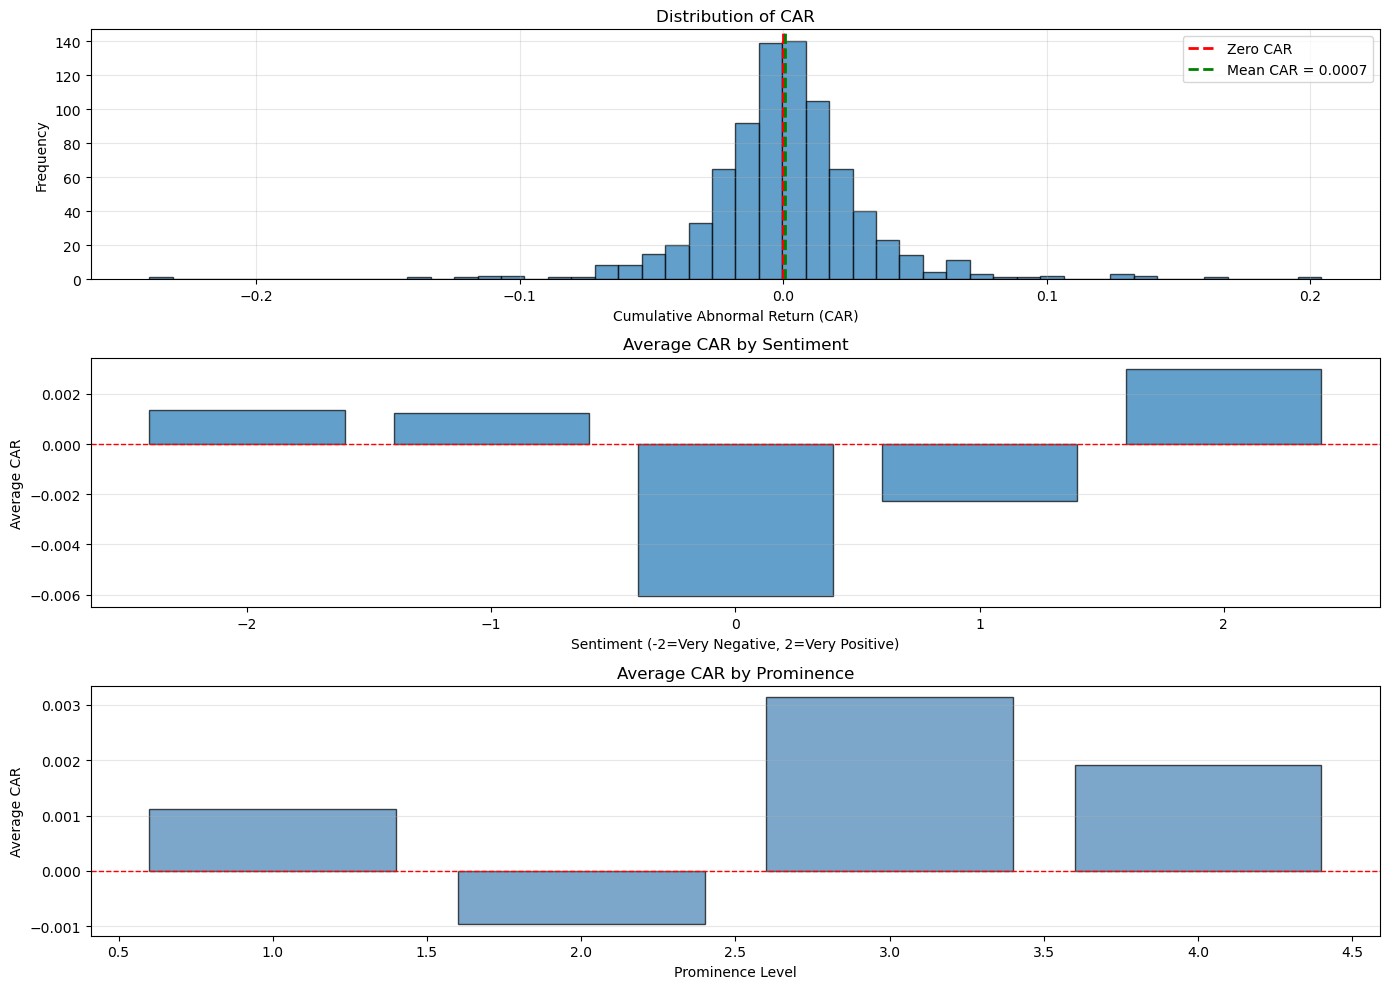

In [264]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# 1. Histogram of CAR
axes[0].hist(car_final['car'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero CAR')
axes[0].axvline(car_final['car'].mean(), color='green', linestyle='--', linewidth=2, label=f'Mean CAR = {car_final["car"].mean():.4f}')
axes[0].set_xlabel('Cumulative Abnormal Return (CAR)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of CAR')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. CAR by Sentiment
sentiment_means = car_final.groupby('sentiment')['car'].mean().sort_index()
axes[1].bar(sentiment_means.index, sentiment_means.values, edgecolor='black', alpha=0.7)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Sentiment (-2=Very Negative, 2=Very Positive)')
axes[1].set_ylabel('Average CAR')
axes[1].set_title('Average CAR by Sentiment')
axes[1].grid(alpha=0.3, axis='y')

# 3. CAR by Prominence
prominence_means = car_final.groupby('prominence')['car'].mean().sort_index()
axes[2].bar(prominence_means.index, prominence_means.values, edgecolor='black', alpha=0.7, color='steelblue')
axes[2].axhline(0, color='red', linestyle='--', linewidth=1)
axes[2].set_xlabel('Prominence Level')
axes[2].set_ylabel('Average CAR')
axes[2].set_title('Average CAR by Prominence')
axes[2].grid(alpha=0.3, axis='y')


plt.tight_layout()
plt.show()

In [265]:
negative_car = (car_final['car'] < 0).sum()
positive_car = (car_final['car'] > 0).sum()
zero_car = (car_final['car'] == 0).sum()

print(f"\nNegative CAR events: {negative_car} ({negative_car/len(car_final)*100:.1f}%)")
print(f"Positive CAR events: {positive_car} ({positive_car/len(car_final)*100:.1f}%)")
print(f"Zero CAR events: {zero_car} ({zero_car/len(car_final)*100:.1f}%)")

# Binomial test: is proportion of negative significantly different from 50%?
from scipy.stats import binomtest
result = binomtest(negative_car, n=negative_car + positive_car, p=0.5, alternative='two-sided')
print(f"\nBinomial test (H0: proportion of negative CAR = 50%):")
print(f"  P-value: {result.pvalue:.4f}")



Negative CAR events: 398 (49.4%)
Positive CAR events: 407 (50.6%)
Zero CAR events: 0 (0.0%)

Binomial test (H0: proportion of negative CAR = 50%):
  P-value: 0.7780


The sign split is essentially even: 49.4% of events have negative CARs (398/805) and 50.6% positive (407/805), with none exactly zero, unsurprising given continuous returns. The binomial test against a 50% benchmark yields p=0.778, so we fail to reject that negatives and positives are equally likely. In plain terms, NGO campaigns don’t tilt market reactions toward losses or gains; outcomes look like a coin flip around zero—consistent with your earlier mean-CAR tests showing no systematic effect by sentiment.

# Conclusion

From our analysis, we can conclude that NGO campaigns against banks, while frequent and often critical, do not lead to statistically significant abnormal stock returns. Given the exploration in task 1, this is not suprising as we saw that the media covergae of campaigns was minimal. Market reactions appear largely indifferent to the sentiment or prominence of these campaigns, suggesting that investors may either quickly price in reputational risks or view NGO activism as a non-material factor in bank valuation. This highlights the complexity of translating social and environmental pressures into tangible financial impacts within the banking sector.